In [1]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from plot_functions import *
from comparison_functions import *
from scipy.interpolate import interp1d


In [2]:
#import classy as classy_pp
import classy_NEDE_Magnus as classy_Magnus
import classy_NEDE_Tobias as classy_Tobias
import classy_SI as classy_reference

In [3]:
model_Magnus_ncdm = run_cosmo(classy_Magnus, get_dict_ncdm())
model_Tobias_ncdm = run_cosmo(classy_Tobias, get_dict_ncdm_pp())
model_reference_ncdm = run_cosmo(classy_reference, get_dict_ncdm_pp())

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-03
Running CLASS version v3.2.5
Computing background
 -> non-cold dark matter species with i=1 has m_i = 1.000000e-05 eV (so m_i / omega_i =1.756884e+00 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
Chose ndf15 as generic_evolver
 -> age = 13.858042 Gyr
 -> conformal age = 14242.901235 Mpc
 -> N_eff = 1.0132 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 4666.945526
    corresponding to conformal time = 96.464596 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0490087       , omega = 0.022          
-> Cold

In [4]:


# Load backgrounds
background_Magnus_ncdm = model_Magnus_ncdm.get_background()
background_Tobias_ncdm = model_Tobias_ncdm.get_background()
background_reference_ncdm = model_reference_ncdm.get_background()

print(background_Magnus_ncdm['z'])
print(background_Tobias_ncdm['z'])

[1.00000000e+14 9.99194400e+13 9.98389448e+13 ... 1.61314959e-03
 8.06249775e-04 0.00000000e+00]
[1.00000000e+14 9.99300219e+13 9.98600928e+13 ... 1.40103227e-03
 7.00270945e-04 0.00000000e+00]


/tmp/ipykernel_120601/912538460.py:28: RuntimeWarning: invalid value encountered in divide
  relative_difference = (background_Magnus_ncdm[key] - Tobias_interp) / background_Magnus_ncdm[key]


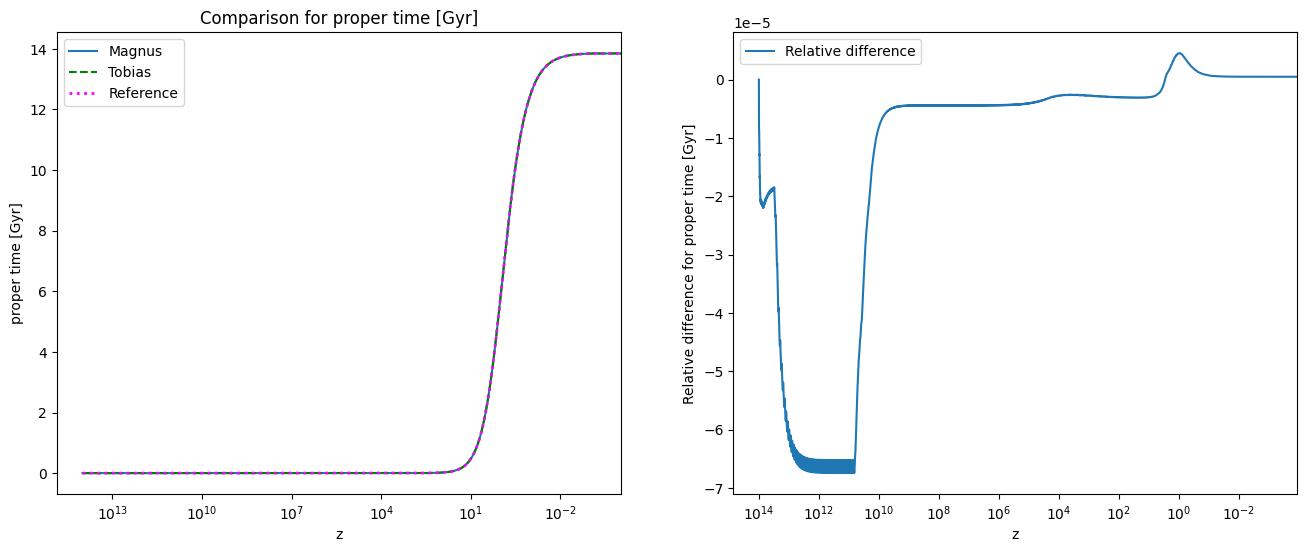

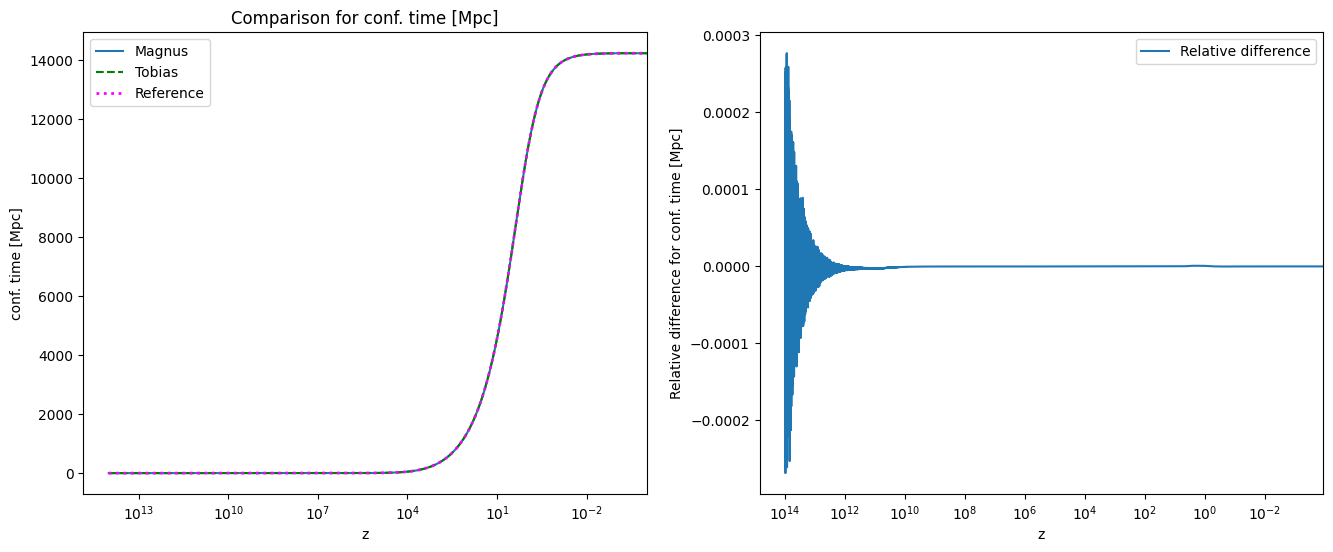

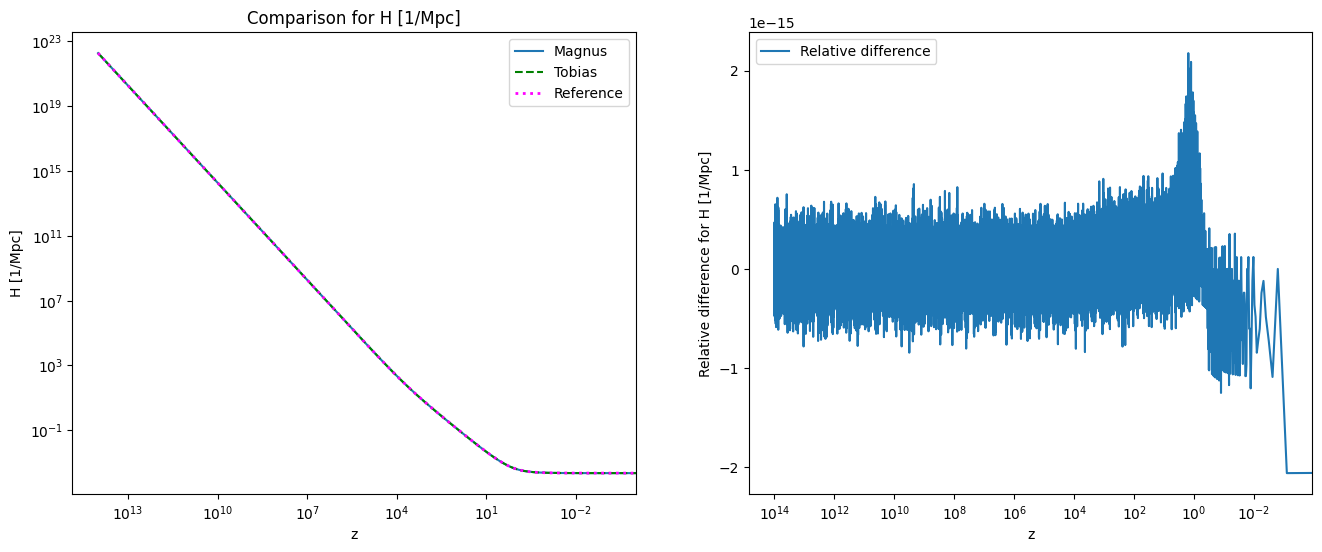

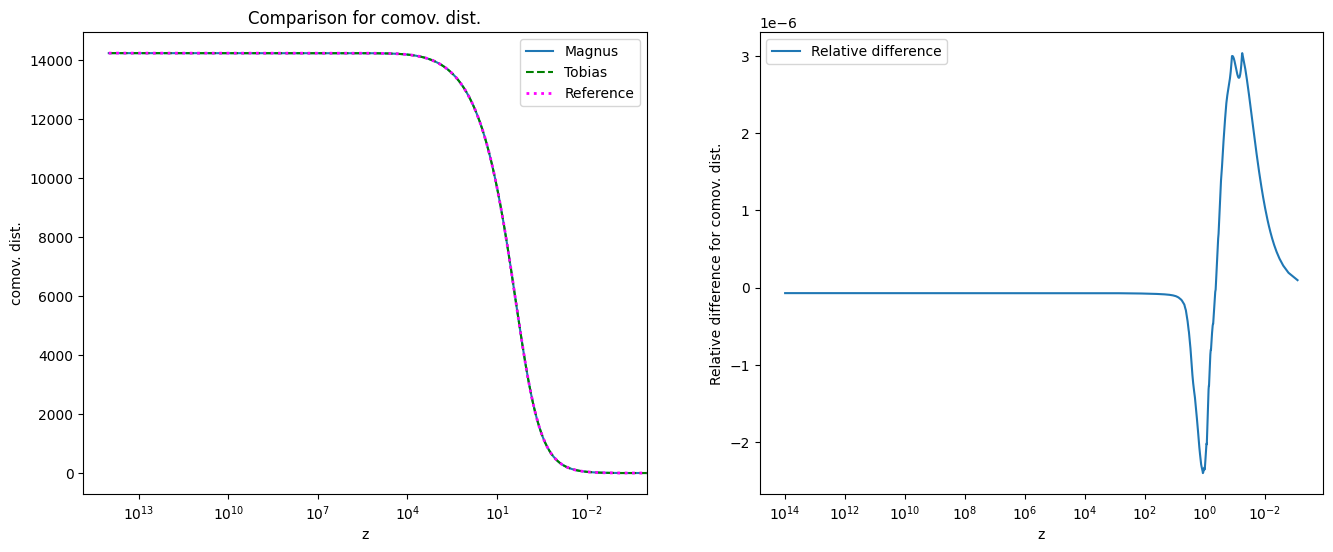

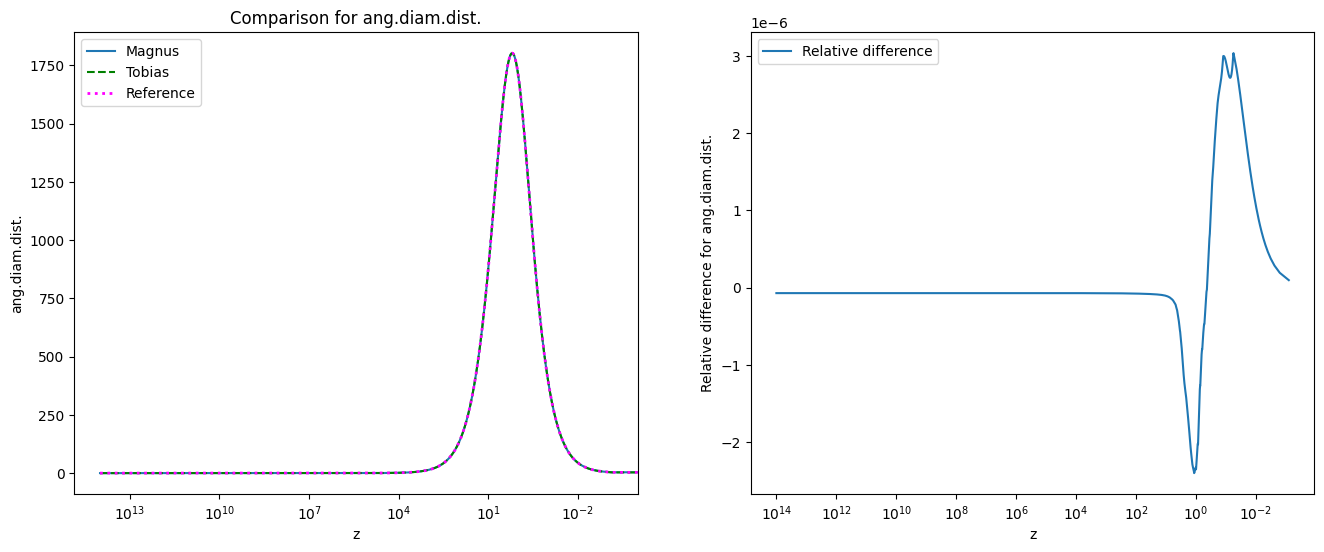

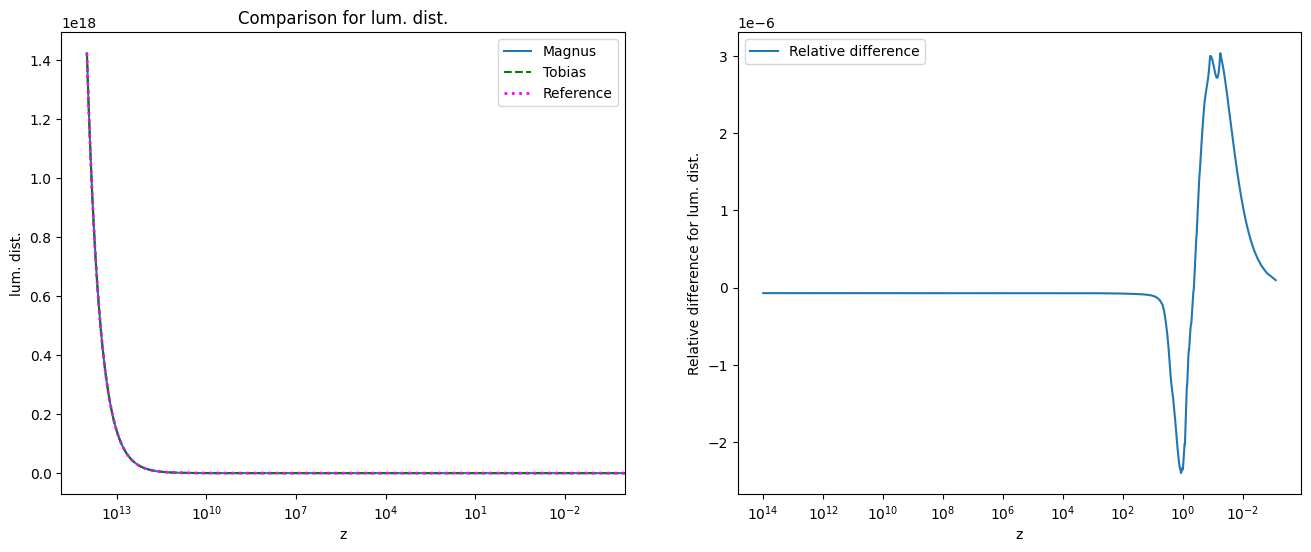

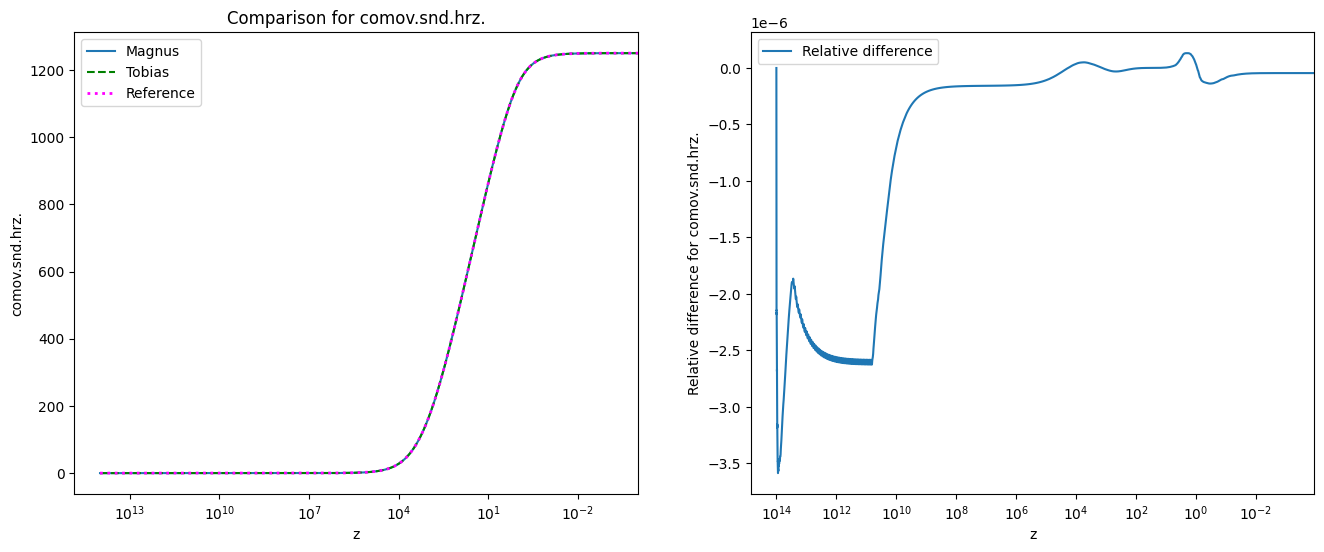

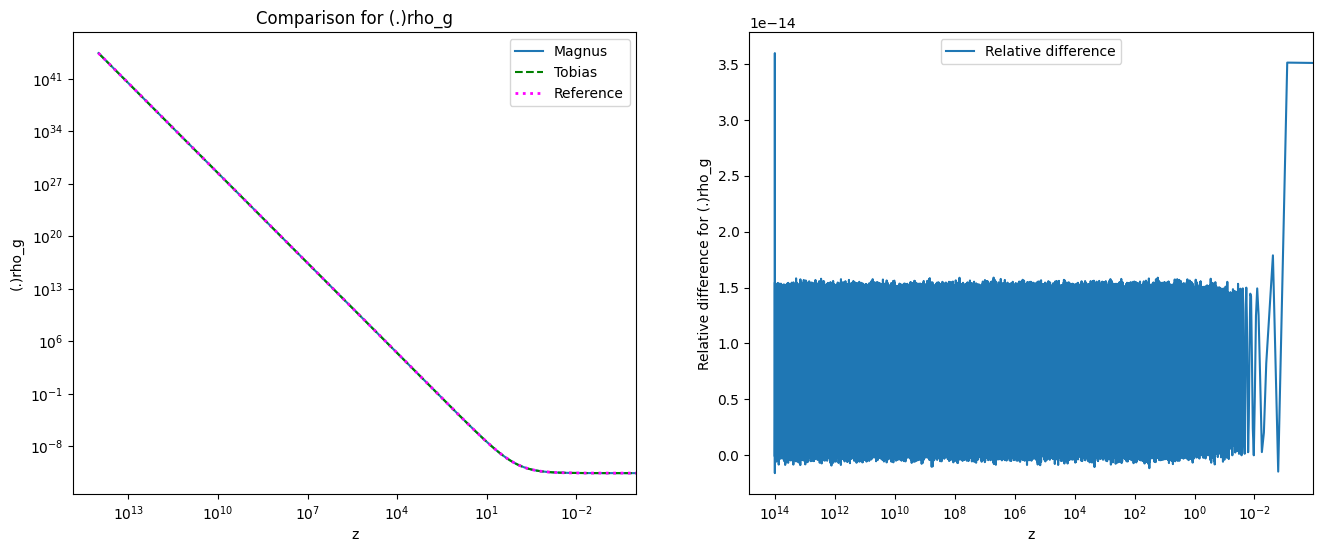

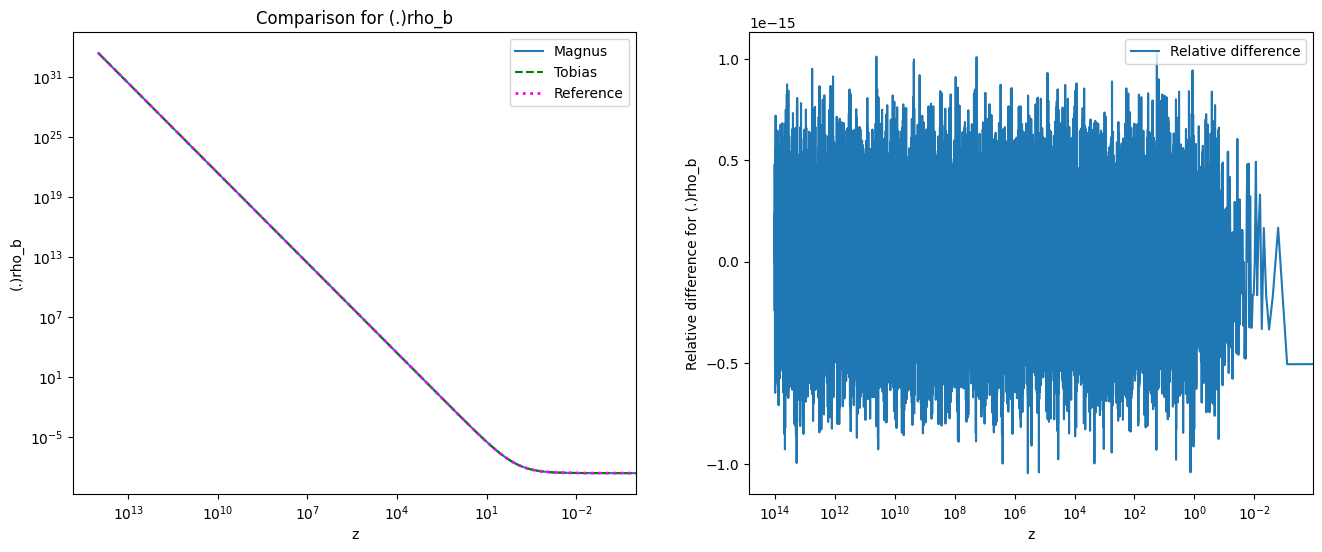

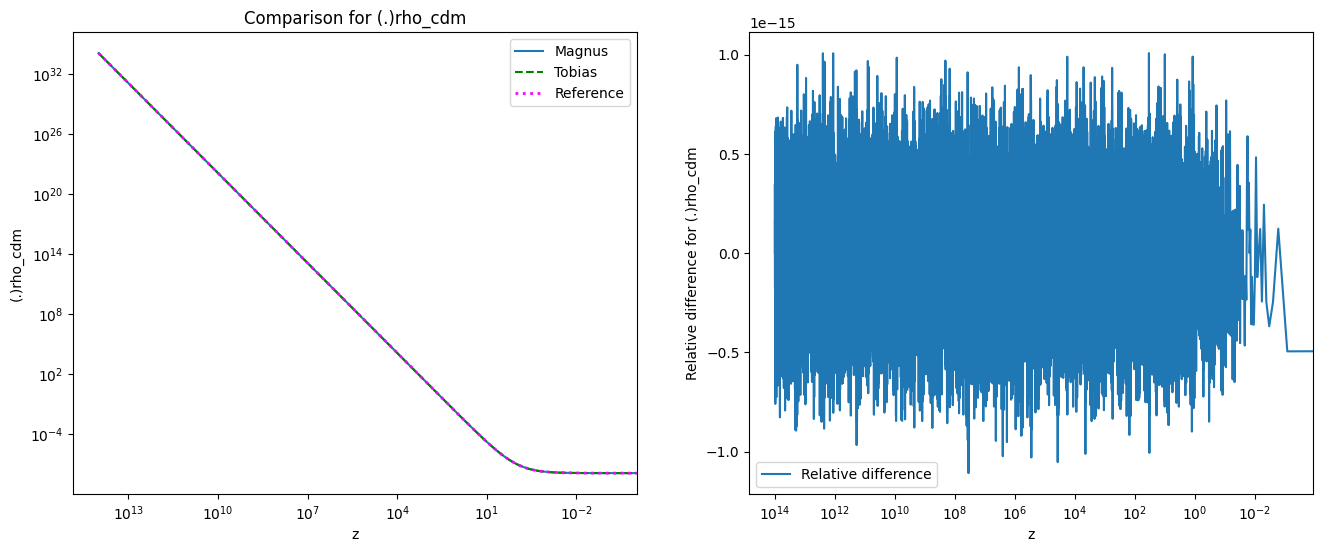

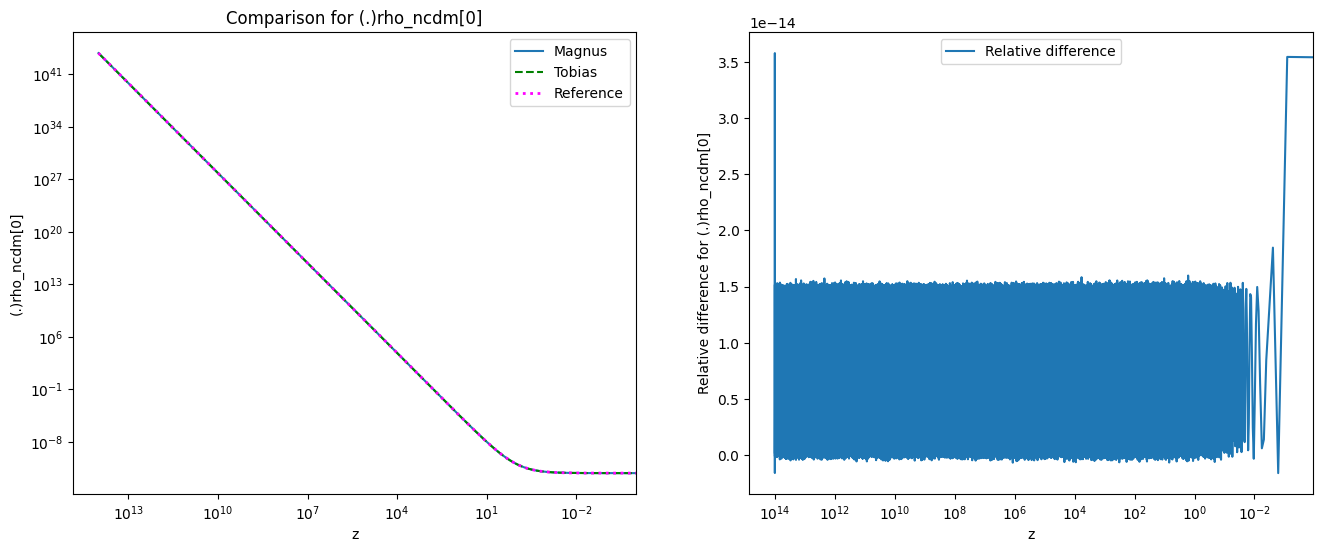

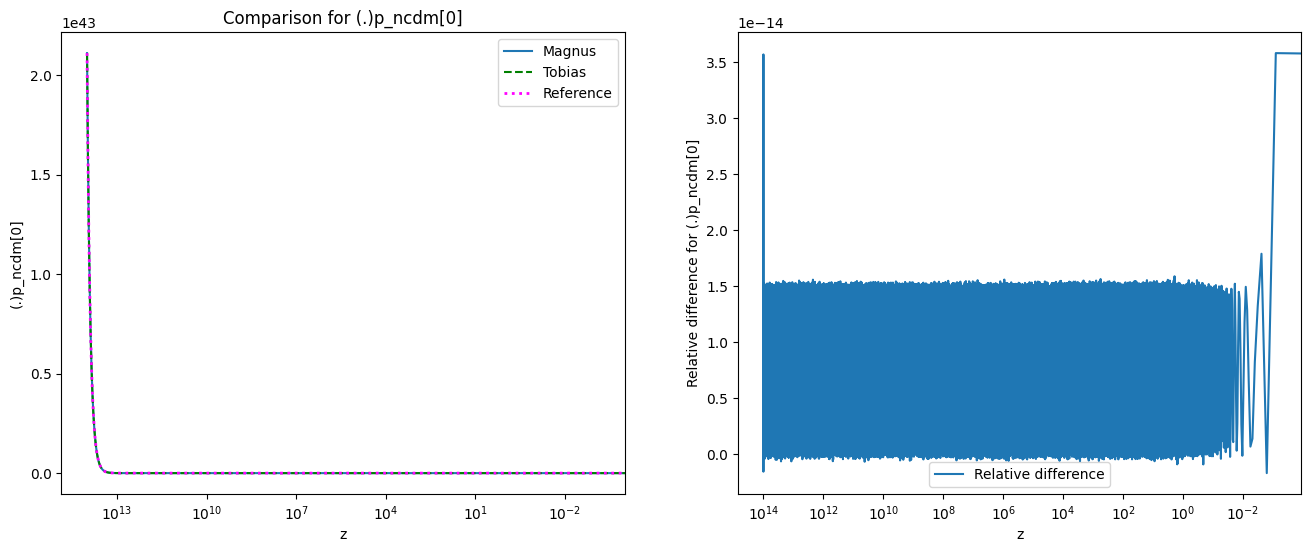

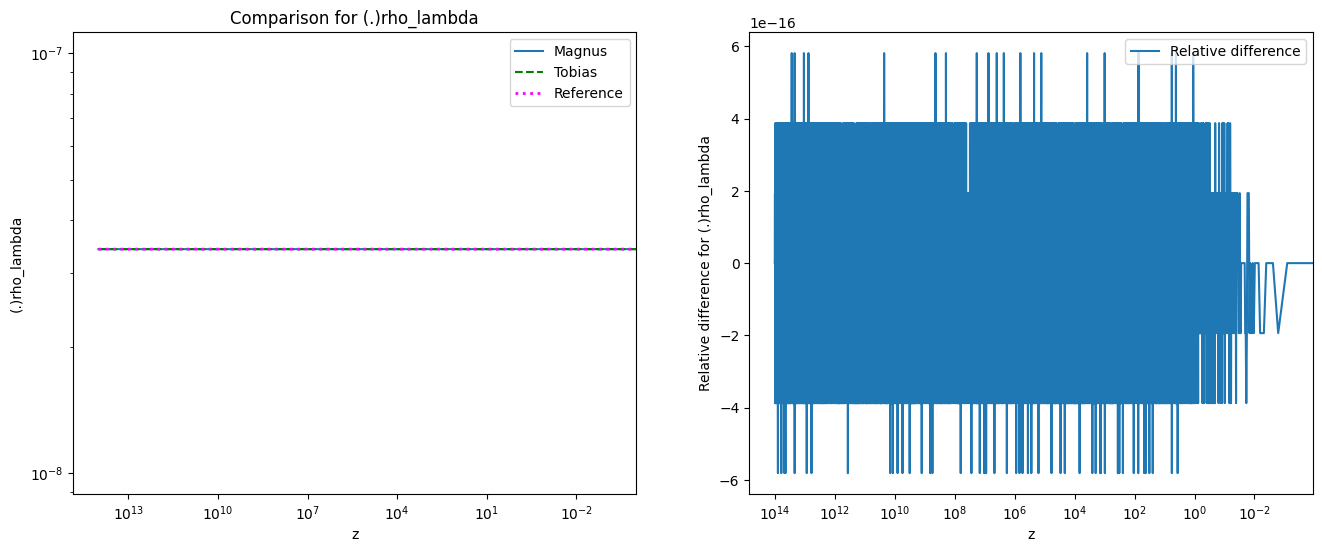

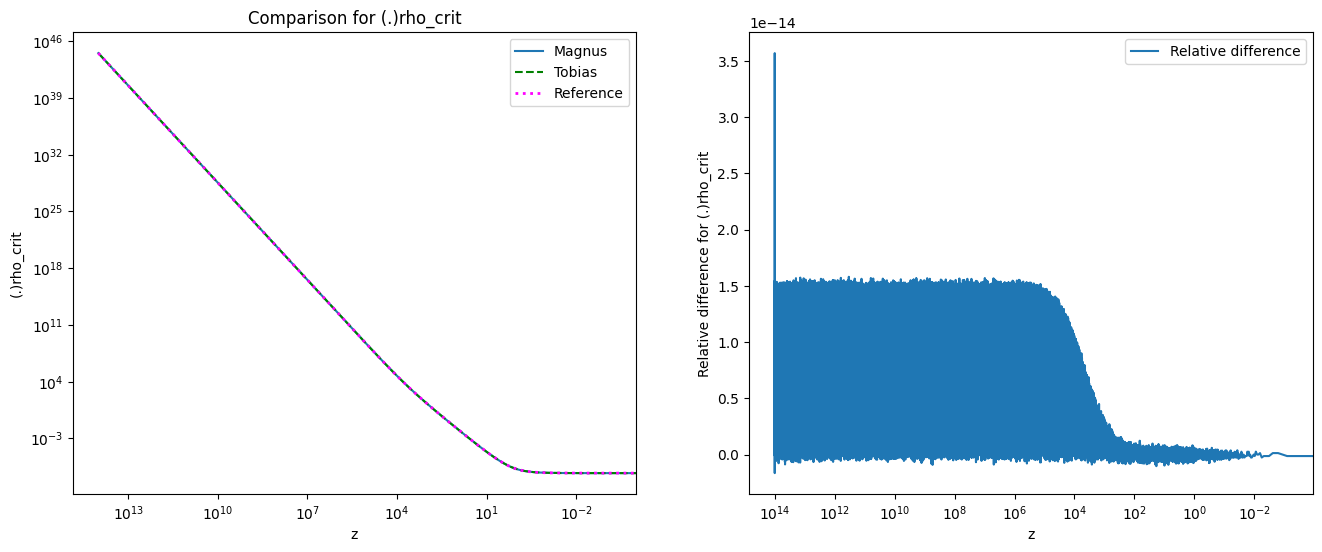

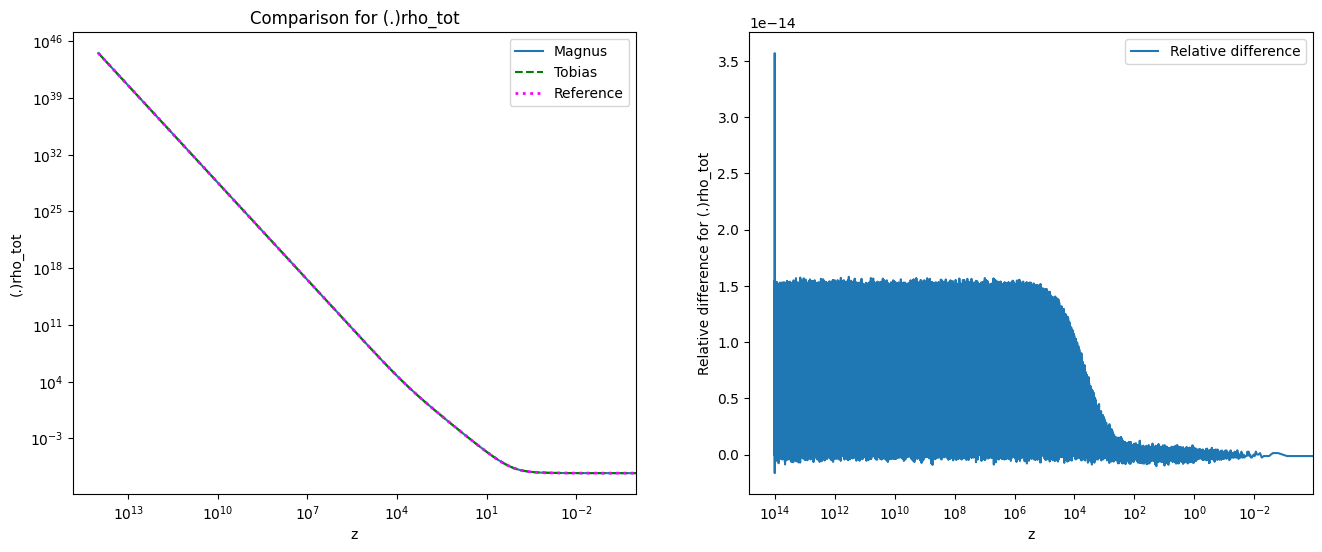

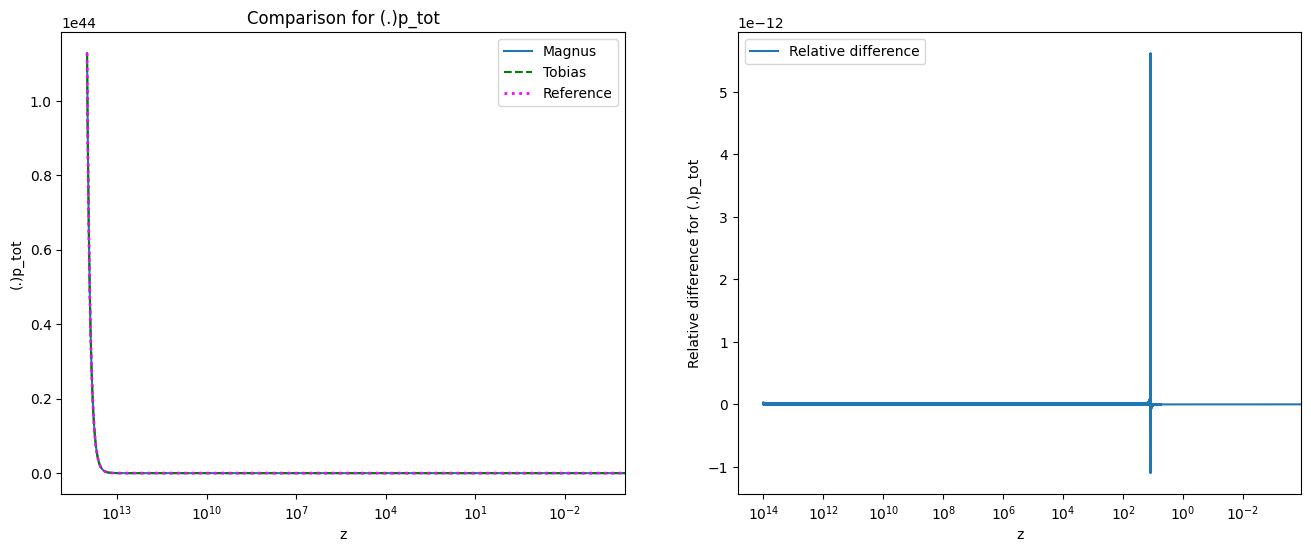

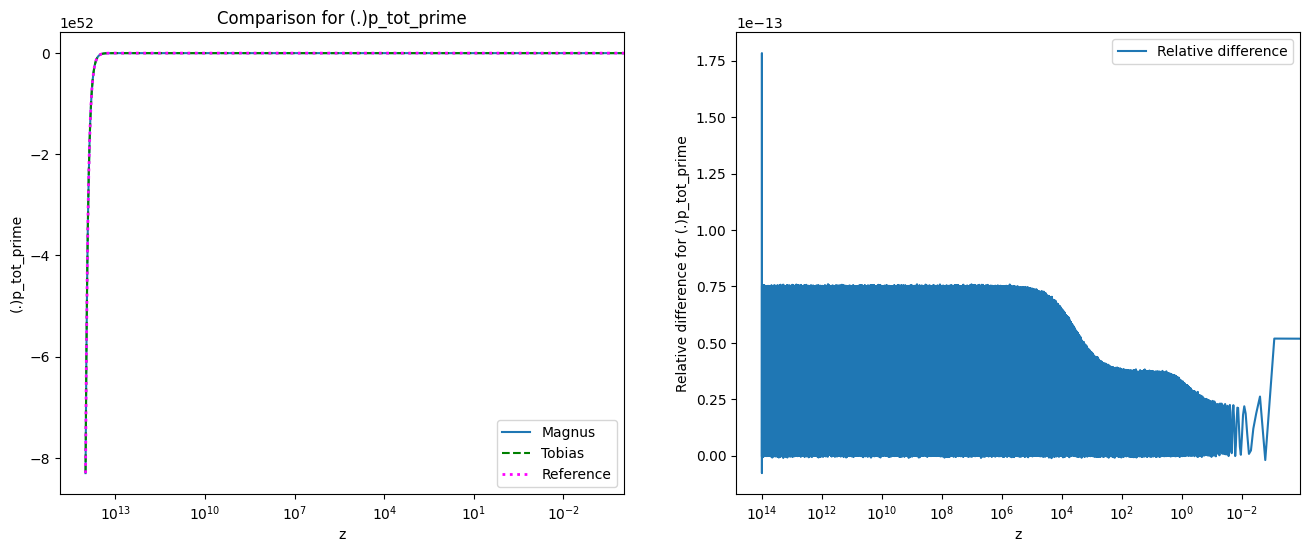

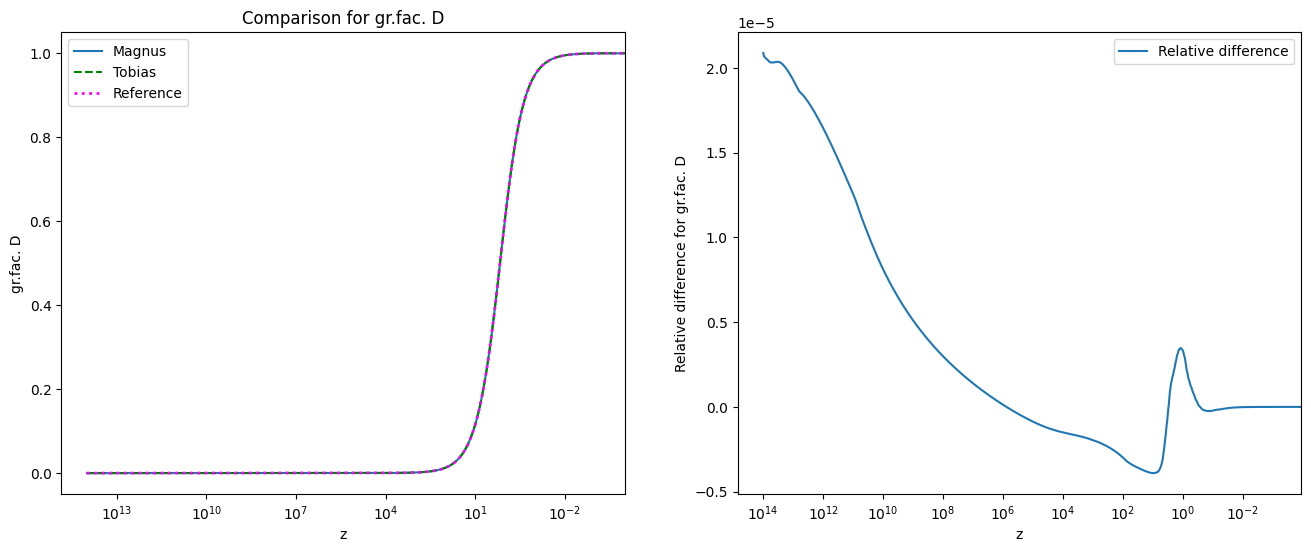

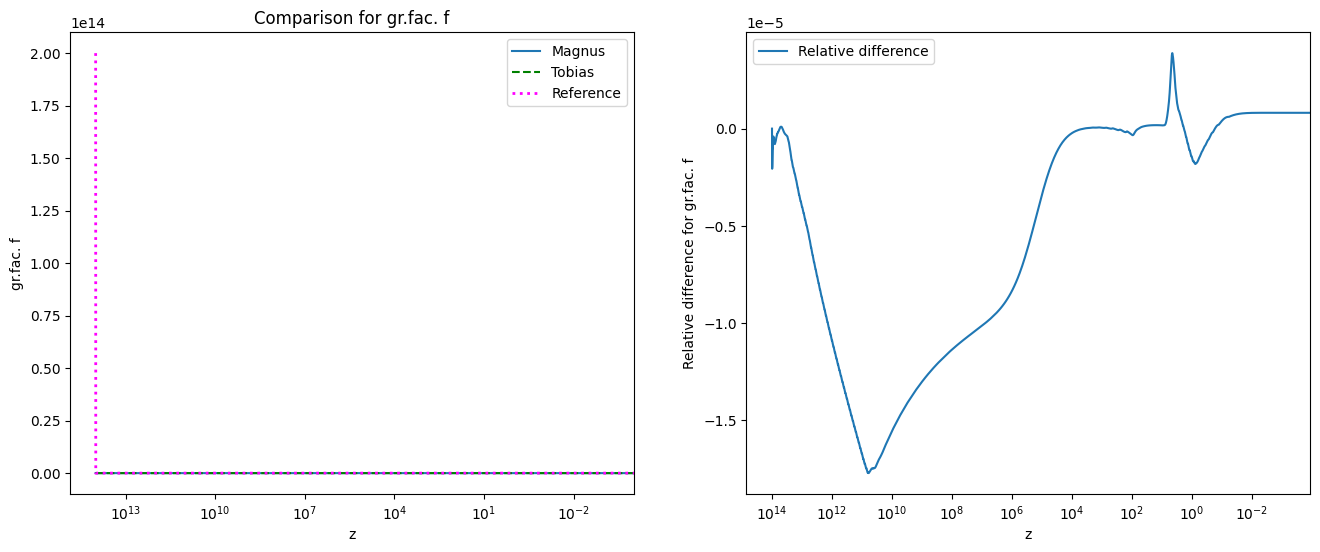

In [5]:
z_magnus = background_Magnus_ncdm['z']
z_tobias = background_Tobias_ncdm['z']
z_reference = background_reference_ncdm['z']


for key in background_Magnus_ncdm.keys():
    if key == 'z':
        continue
    

    fig, axs = plt.subplots(1,2,figsize=(16,6))
    
    axs[0].plot(z_magnus, background_Magnus_ncdm[key], label='Magnus', ls='solid')
    axs[0].plot(z_tobias, background_Tobias_ncdm[key], label='Tobias', ls='dashed', color = 'green')
    axs[0].plot(z_reference, background_reference_ncdm[key], label='Reference', ls='dotted', lw =2, color = 'magenta')
    axs[0].set(xlabel='z', ylabel=key, xscale='log')
    axs[0].invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    axs[0].set_title(f'Comparison for {key}')
    axs[0].legend()
    if 'rho' in key or 'H' in key:
        axs[0].set_yscale('log')


    #Create a logscale plot of the relative difference between Magnus and Tobias. First, we need to interpolate the Tobias data to the same z values as Magnus.
    interp_Tobias = interp1d(z_tobias, background_Tobias_ncdm[key], kind='cubic', fill_value='extrapolate')
    Tobias_interp = interp_Tobias(z_magnus)

    relative_difference = (background_Magnus_ncdm[key] - Tobias_interp) / background_Magnus_ncdm[key]
    axs[1].plot(z_magnus, relative_difference, label='Relative difference', ls='solid')
    axs[1].set(xlabel='z', ylabel=f'Relative difference for {key}', xscale='log')
    axs[1].invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    axs[1].legend()

scale factor a
z
conf. time [Mpc]
x_e
kappa' [Mpc^-1]
exp(-kappa)
g [Mpc^-1]
Tb [K]
dTb [K]
w_b
c_b^2
tau_d


/tmp/ipykernel_120601/841844191.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  ratio_Magnus = np.max(val_Magnus) / np.min(val_Magnus)
/tmp/ipykernel_120601/841844191.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  ratio_Tobias = np.max(val_Tobias) / np.min(val_Tobias)
/tmp/ipykernel_120601/841844191.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  ratio_reference = np.max(val_reference) / np.min(val_reference)
/tmp/ipykernel_120601/841844191.py:40: RuntimeWarning: divide by zero encountered in divide
  relative_difference = (thermodynamics_Magnus_ncdm[key] - Tobias_interp) / thermodynamics_Magnus_ncdm[key]
/tmp/ipykernel_120601/841844191.py:40: RuntimeWarning: invalid value encountered in divide
  relative_difference = (thermodynamics_Magnus_ncdm[key] - Tobias_interp) / thermodynamics_Magnus_ncdm[key]
/tmp/ipykernel_120601/841844191.py:21: RuntimeWarning: overflow encountered in scalar divide
  ratio_Magnus = np.max(val_Mag

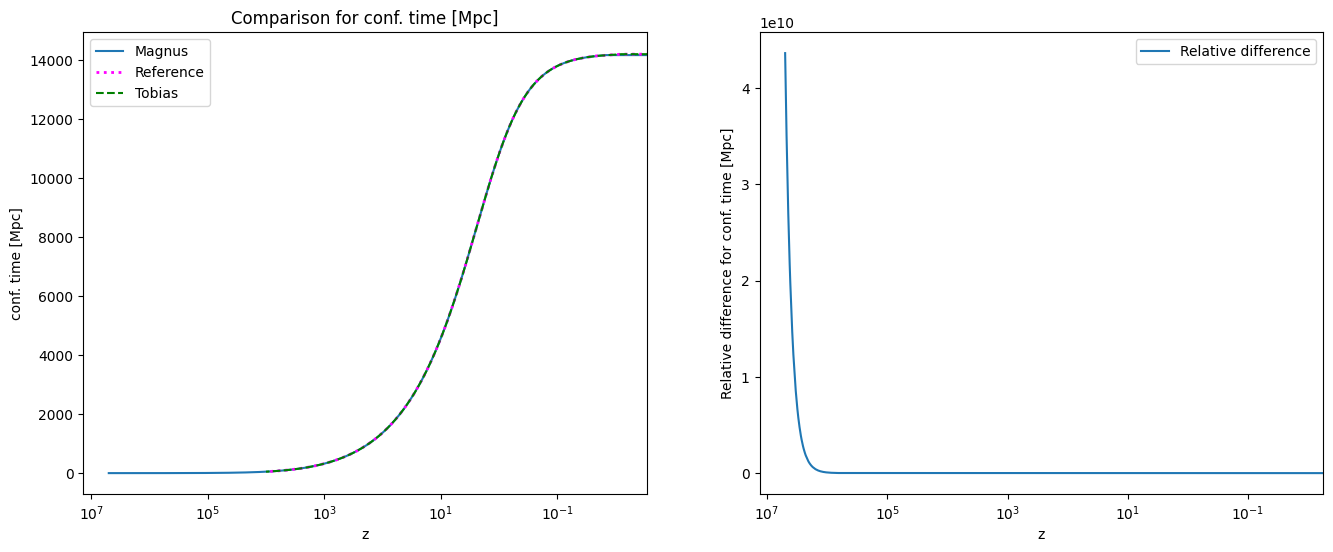

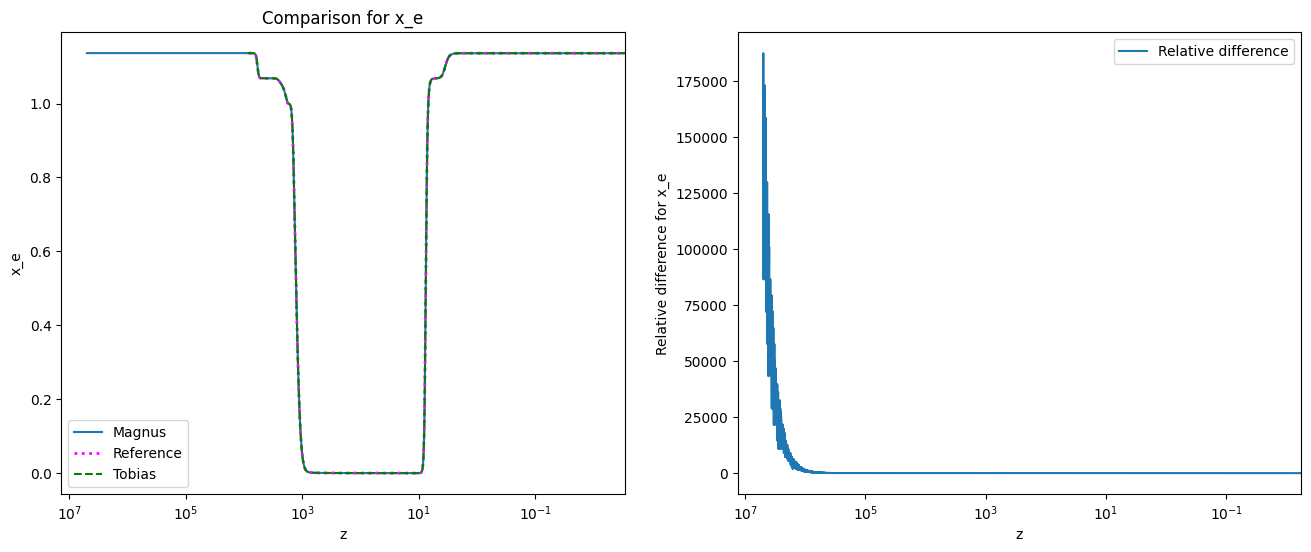

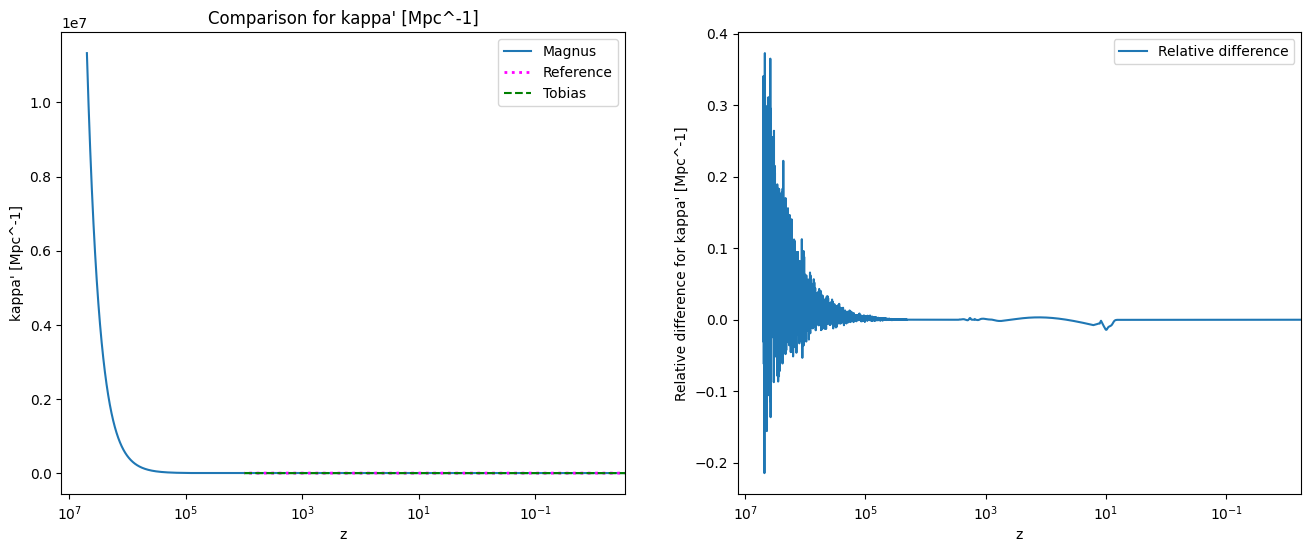

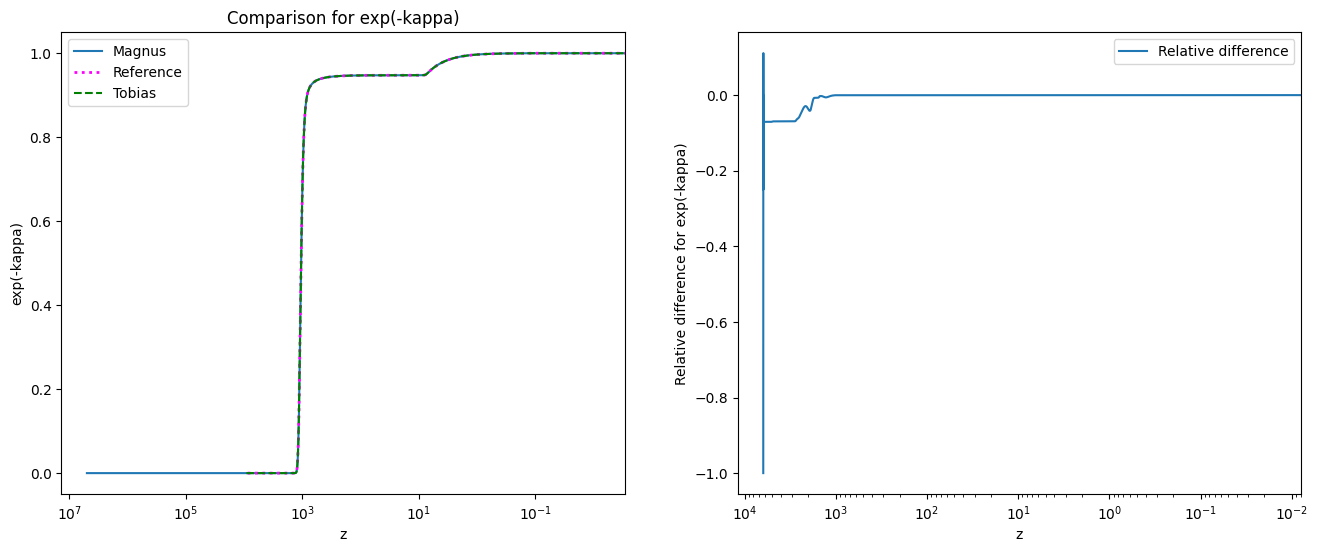

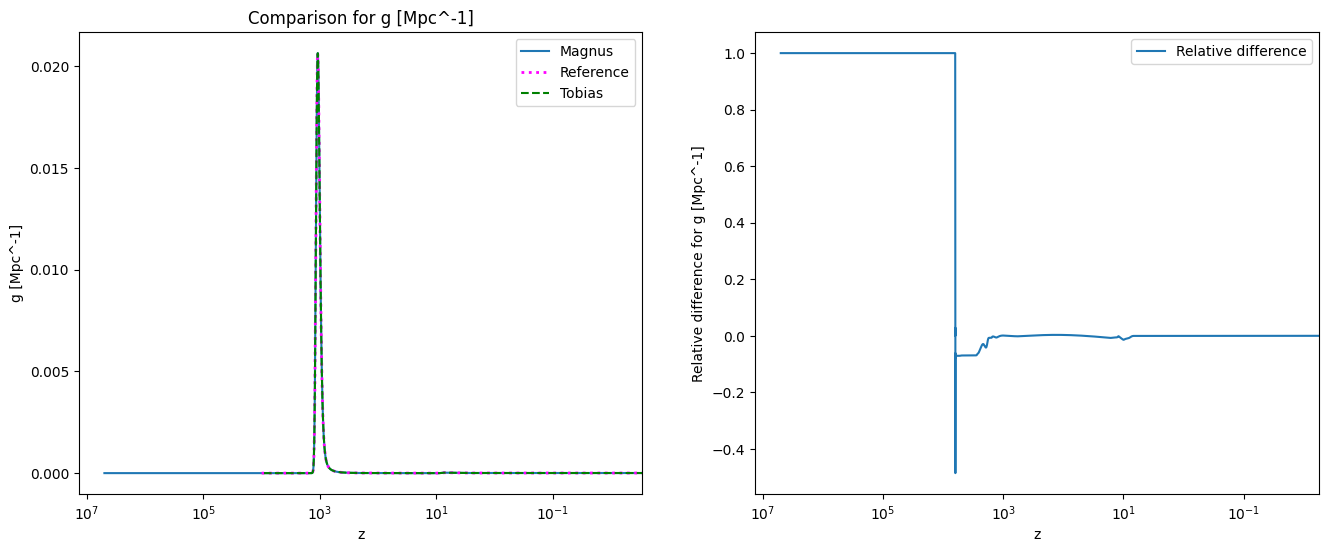

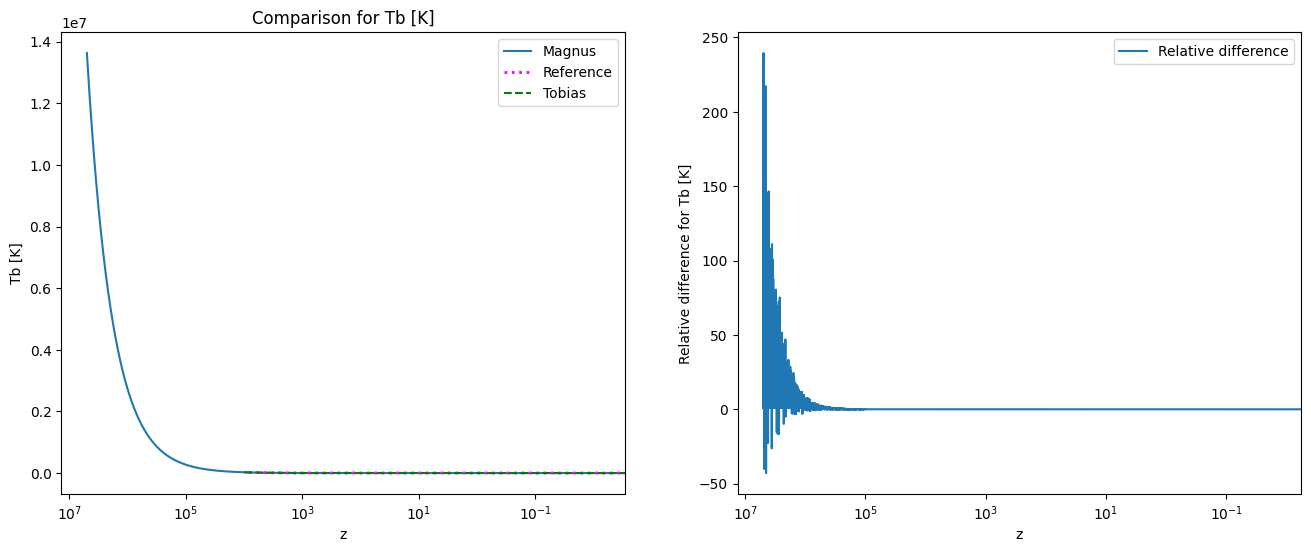

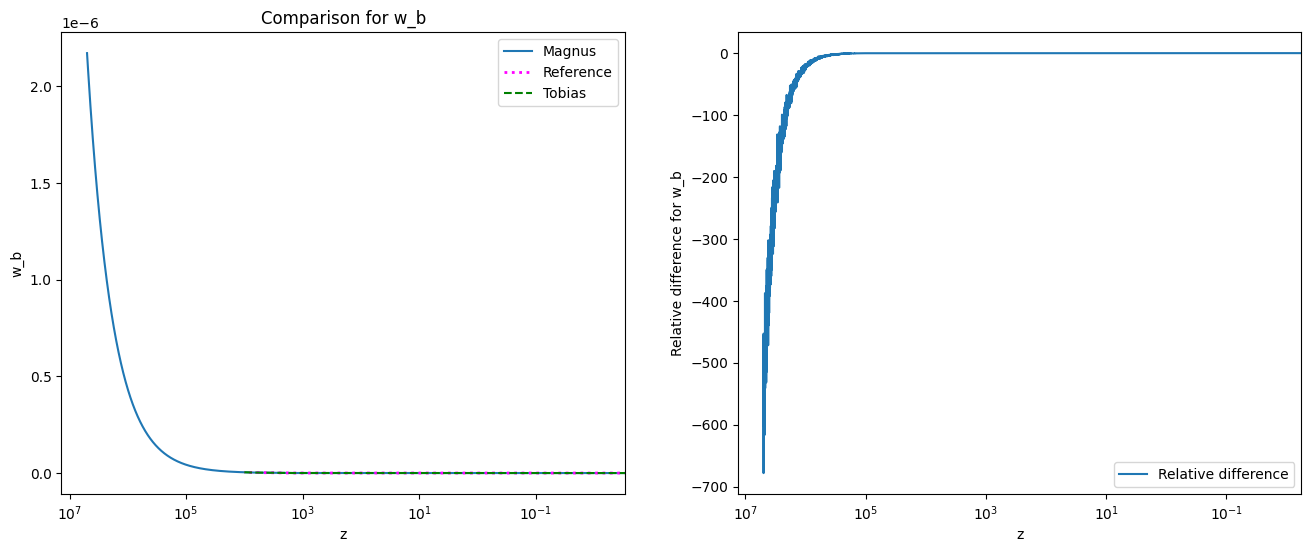

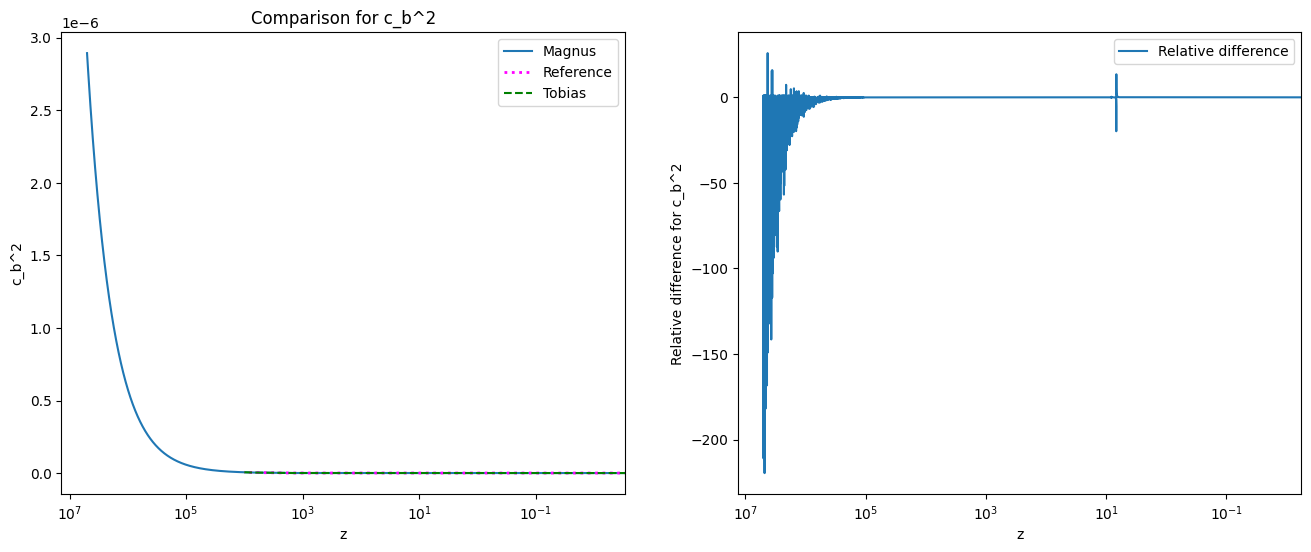

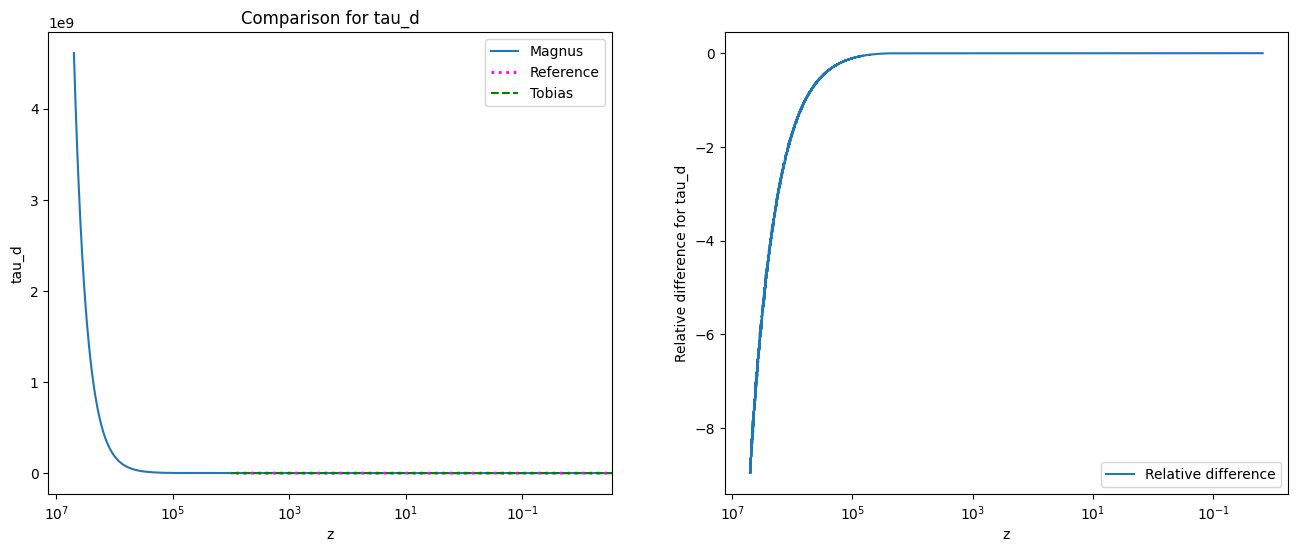

In [6]:
thermodynamics_Magnus_ncdm = model_Magnus_ncdm.get_thermodynamics()
thermodynamics_Tobias_ncdm = model_Tobias_ncdm.get_thermodynamics()
thermodynamics_reference_ncdm = model_reference_ncdm.get_thermodynamics()

for key in thermodynamics_Magnus_ncdm.keys():
    print(key)
z_Magnus = thermodynamics_Magnus_ncdm['z']
z_reference = thermodynamics_reference_ncdm['z']
z_Tobias = thermodynamics_Tobias_ncdm['z']

for key in thermodynamics_Tobias_ncdm.keys():
    if key == 'z' or key == 'scale factor a':
        continue
    fig, axs = plt.subplots(1,2,figsize=(16,6))

    val_Magnus = thermodynamics_Magnus_ncdm[key]
    val_Tobias = thermodynamics_Tobias_ncdm[key]
    val_reference = thermodynamics_reference_ncdm[key]

    #If the order of magnitude of the values is very different, we can plot them on a log scale. We can check this by looking at the ratio of the maximum to minimum value for each dataset. If the ratio is greater than 100, we can plot on a log scale.
    ratio_Magnus = np.max(val_Magnus) / np.min(val_Magnus)
    ratio_Tobias = np.max(val_Tobias) / np.min(val_Tobias)
    ratio_reference = np.max(val_reference) / np.min(val_reference)




    axs[0].plot(z_Magnus, thermodynamics_Magnus_ncdm[key], label='Magnus', ls='solid')
    axs[0].plot(z_reference, thermodynamics_reference_ncdm[key], label='Reference', ls='dotted', lw =2, color = 'magenta')
    axs[0].plot(z_Tobias, thermodynamics_Tobias_ncdm[key], label='Tobias', ls='dashed', color = 'green')
    axs[0].set(xlabel='z', ylabel=key, xscale='log')
    axs[0].set_title(f'Comparison for {key}')
    axs[0].invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    axs[0].legend()

    #Create a logscale plot of the relative difference between Magnus and Tobias. First, we need to interpolate the Tobias data to the same a values as Magnus.
    interp_Tobias = interp1d(z_Tobias, thermodynamics_Tobias_ncdm[key], kind='cubic', fill_value='extrapolate')
    Tobias_interp = interp_Tobias(z_Magnus)

    relative_difference = (thermodynamics_Magnus_ncdm[key] - Tobias_interp) / thermodynamics_Magnus_ncdm[key]
    axs[1].plot(z_Magnus, relative_difference, label='Relative difference', ls='solid')
    axs[1].set(xlabel='z', ylabel=f'Relative difference for {key}', xscale='log')
    axs[1].legend()
    axs[1].invert_xaxis()  # Invert x-axis to have z decreasing from left to right

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-03
tau [Mpc]
a
delta_g
theta_g
shear_g
pol0_g
pol1_g
pol2_g
delta_b
theta_b
psi
phi
delta_cdm
theta_cdm
delta_ncdm[0]
theta_ncdm[0]
shear_ncdm[0]
cs2_ncdm[0]
tau [Mpc]
a
delta_g
theta_g
shear_g
pol0_g
pol1_g
pol2_g
delta_b
theta_b
psi
phi
delta_cdm
theta_cdm
delta_ncdm[0]
theta_ncdm[0]
shear_ncdm[0]
cs2_ncdm[0]


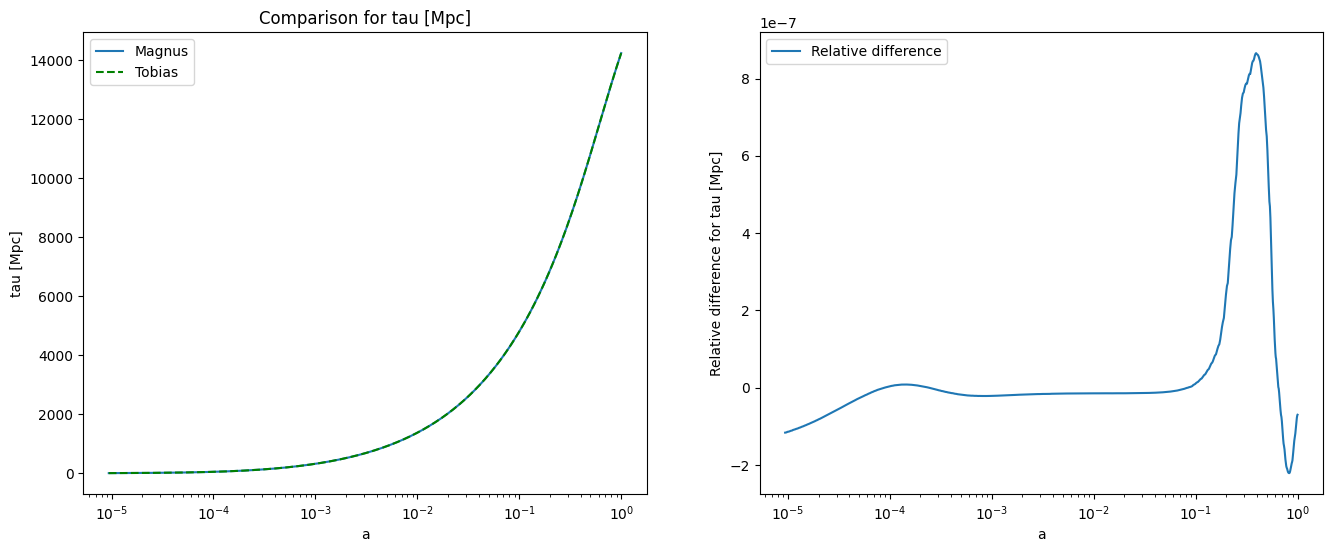

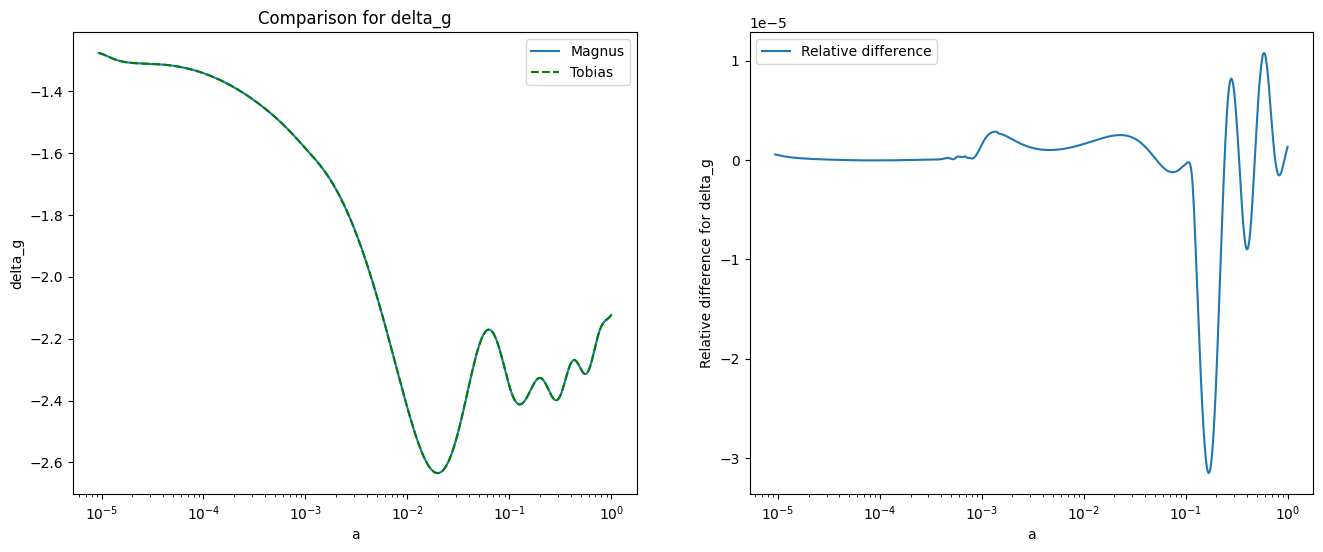

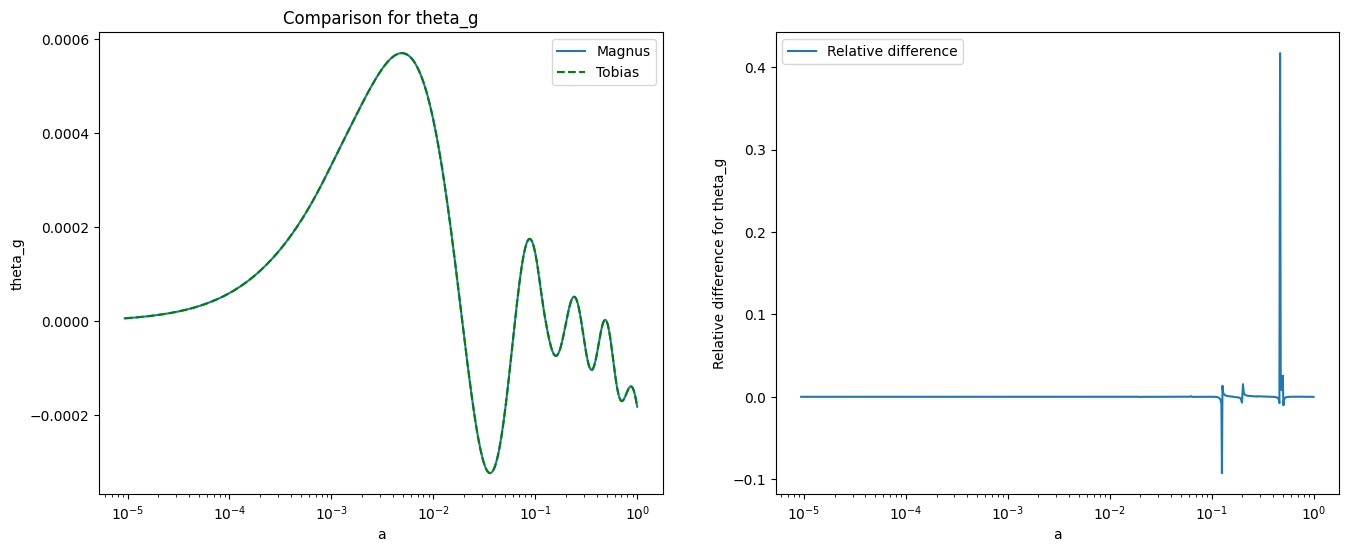

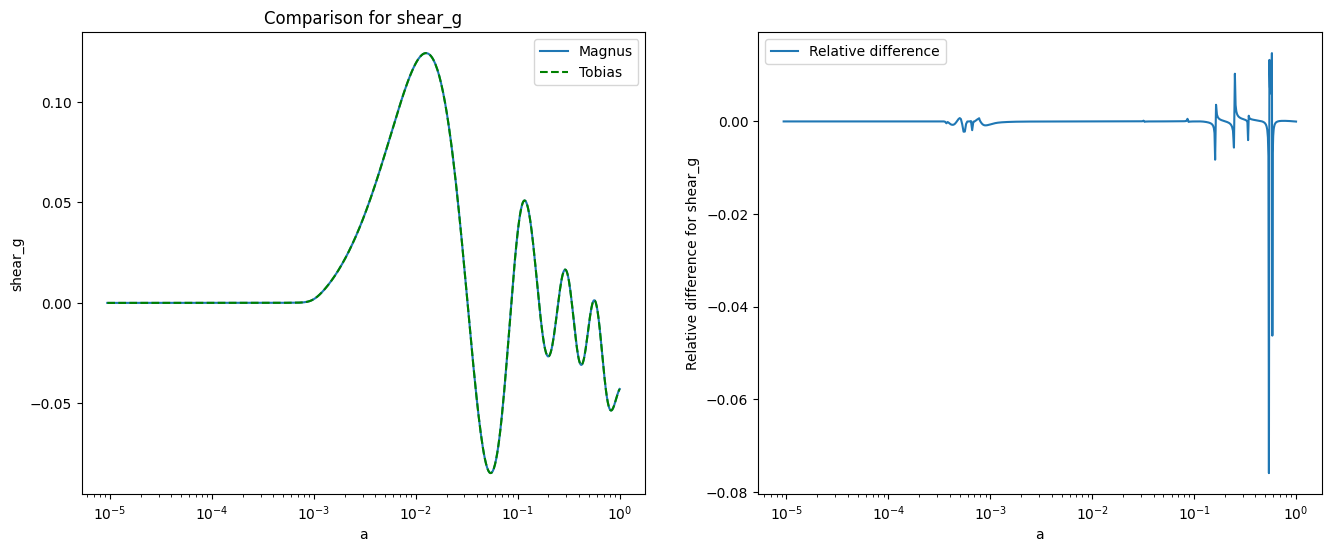

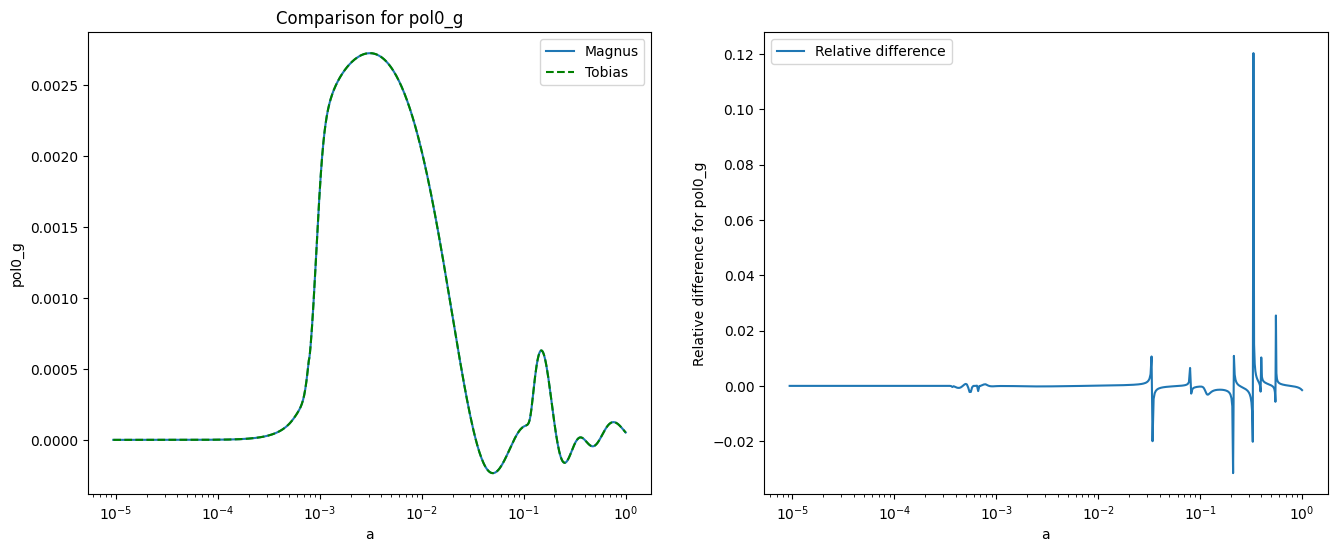

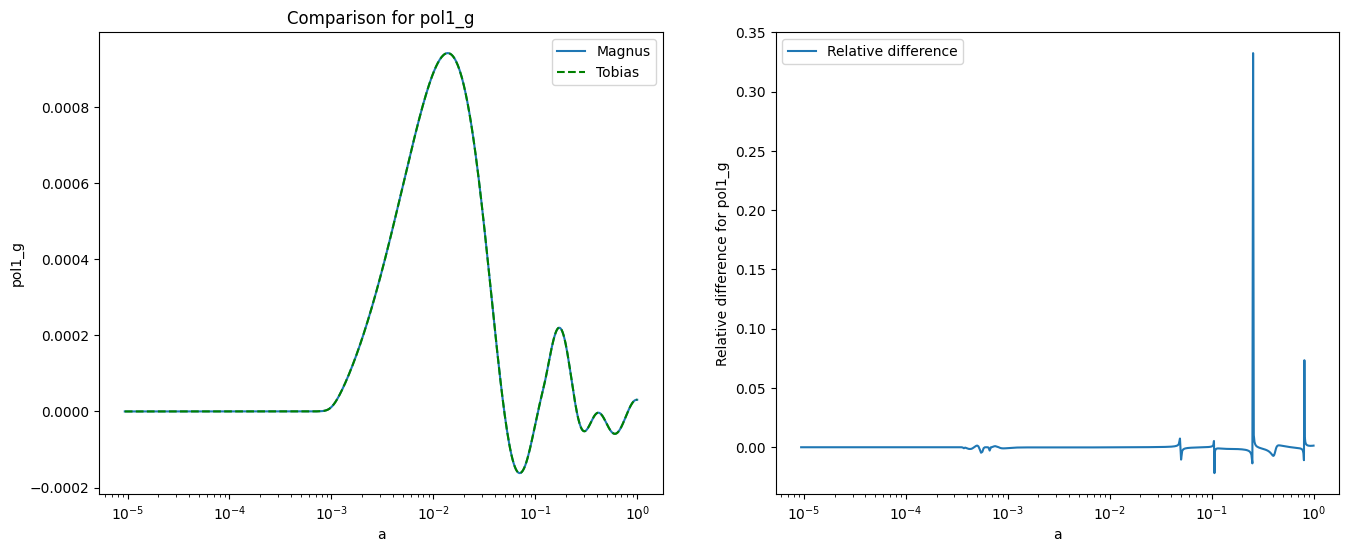

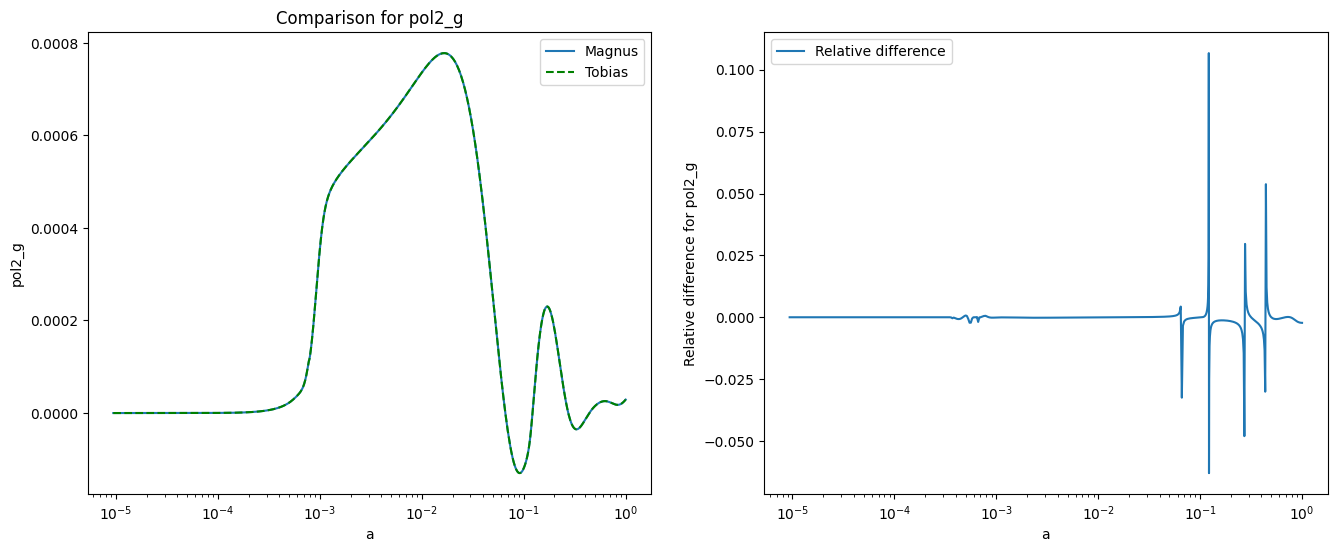

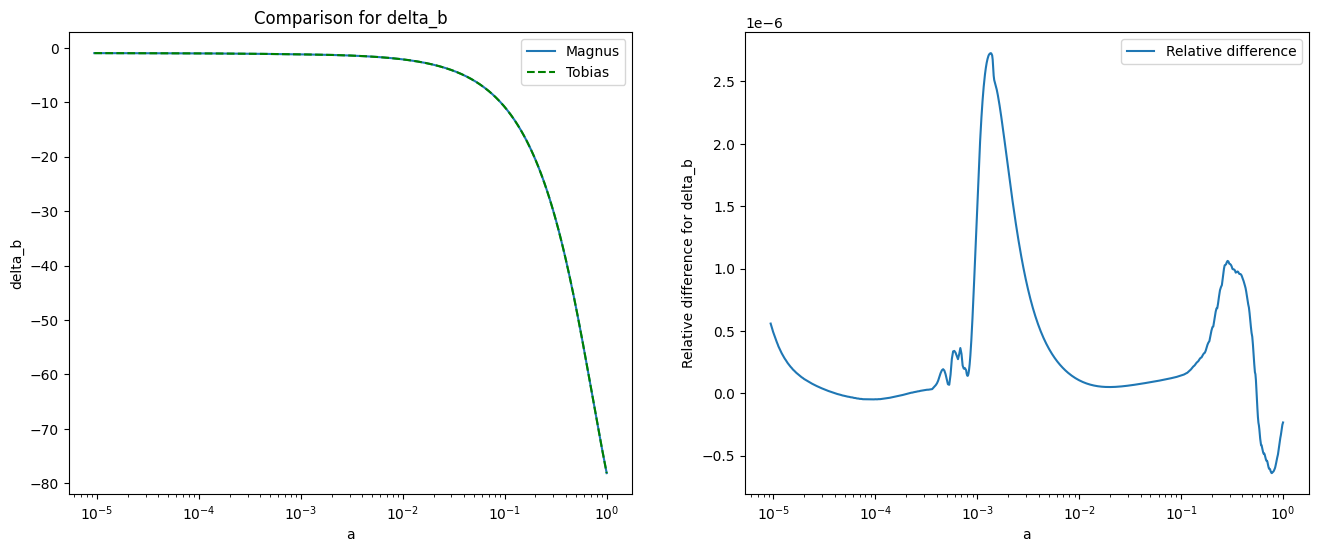

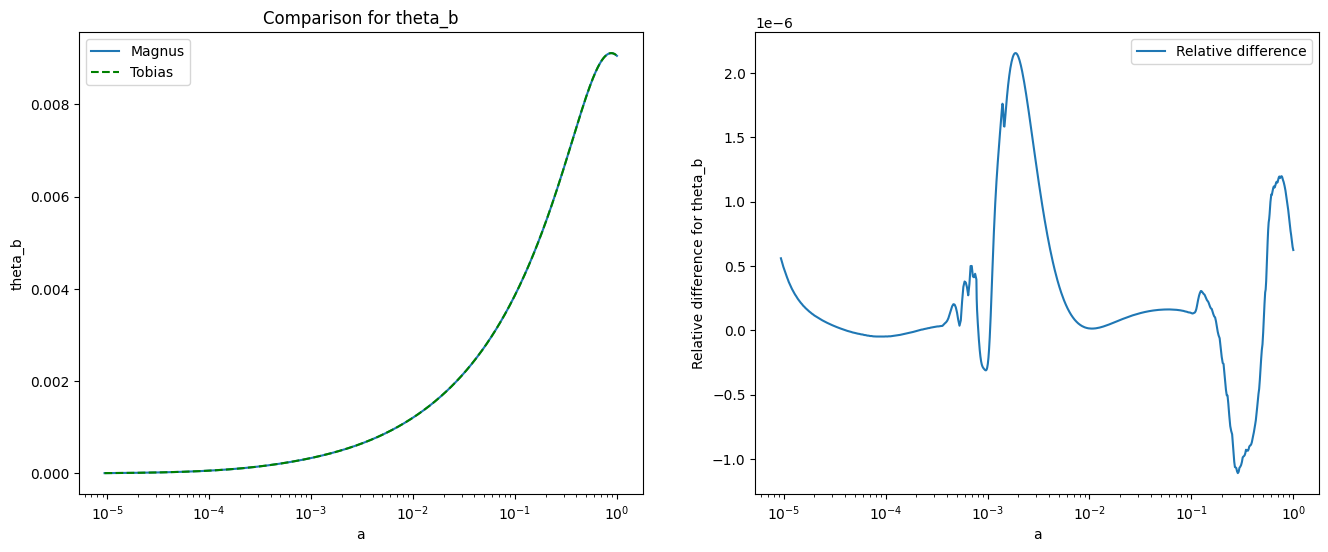

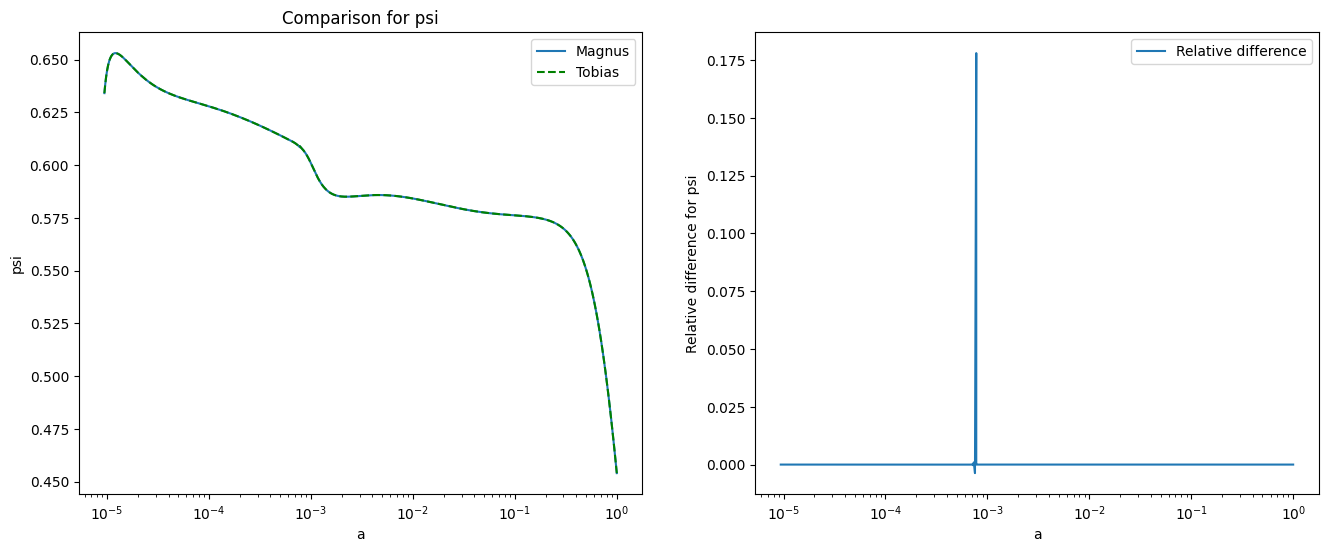

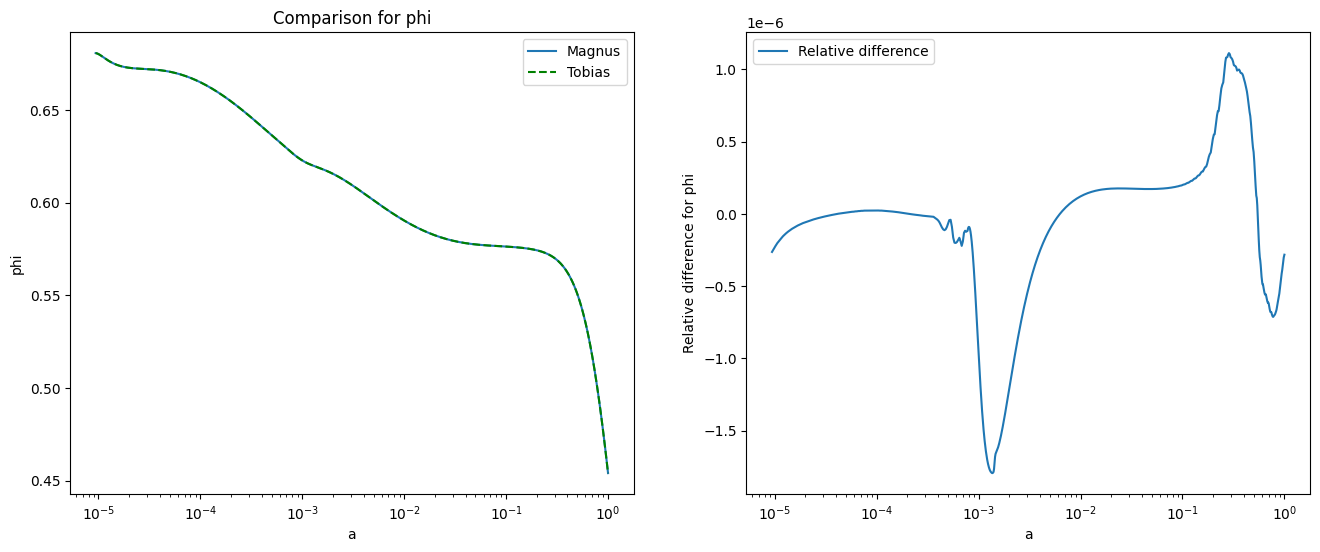

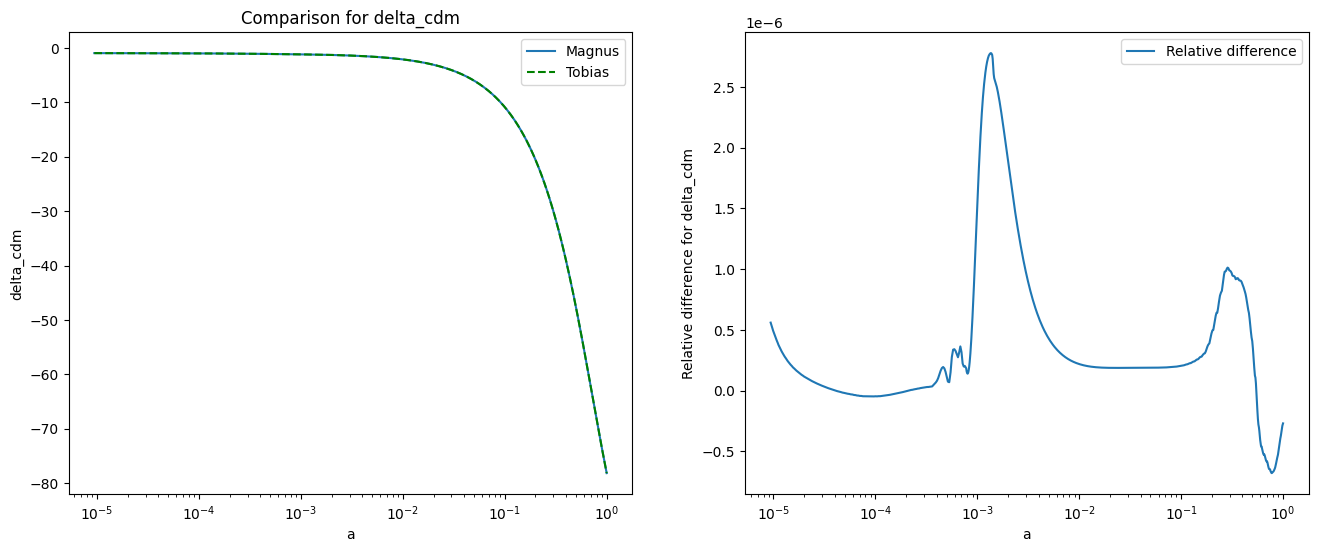

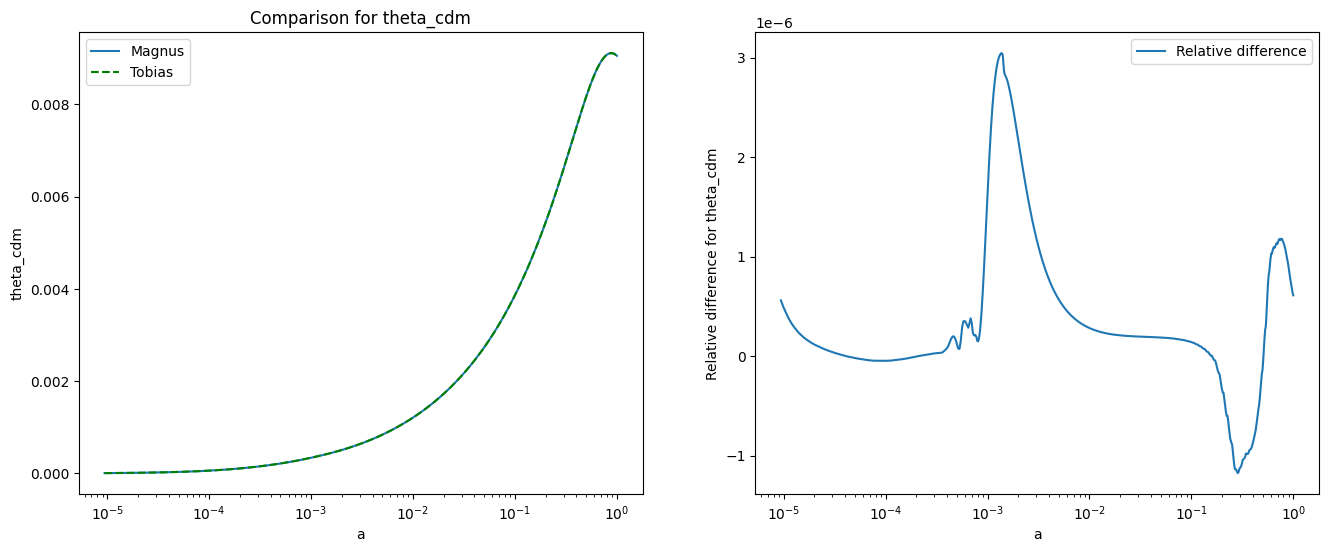

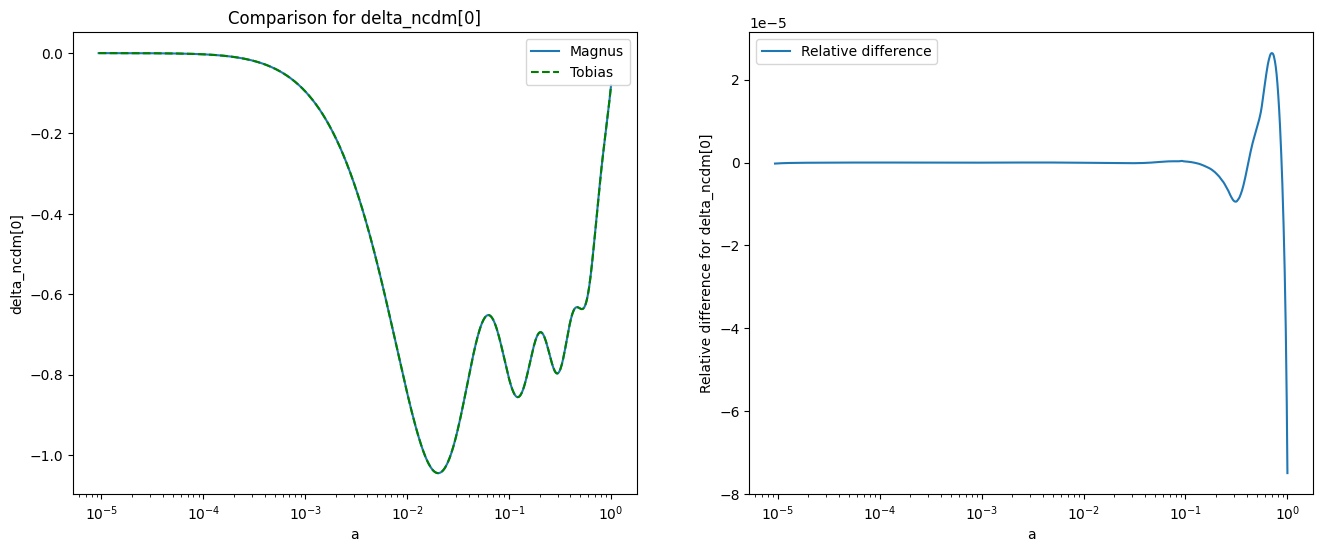

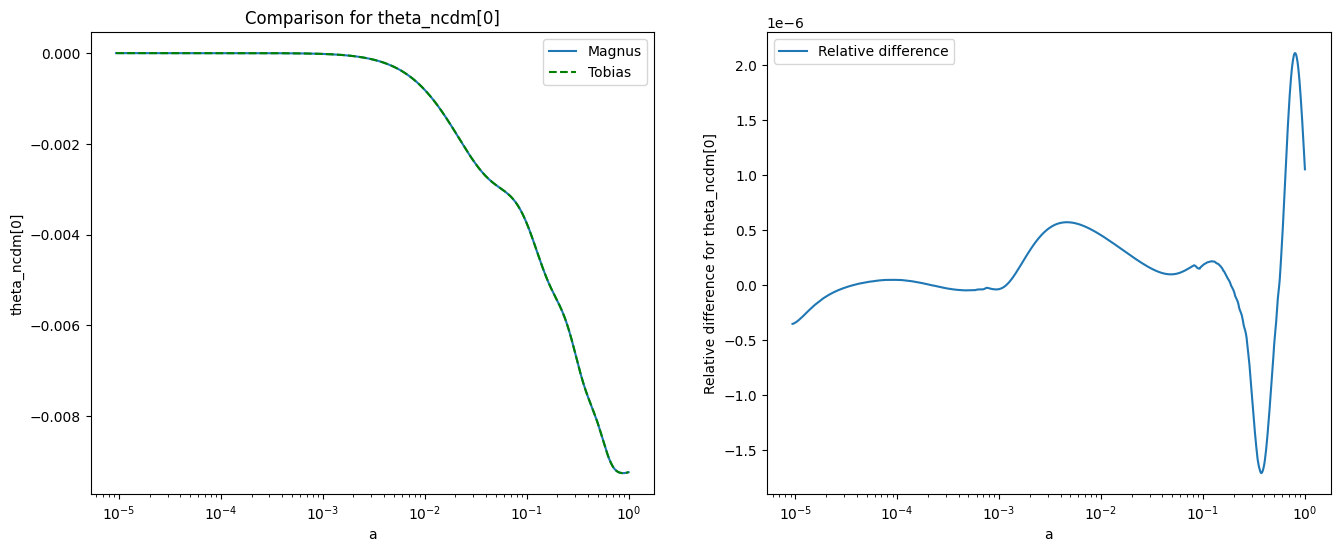

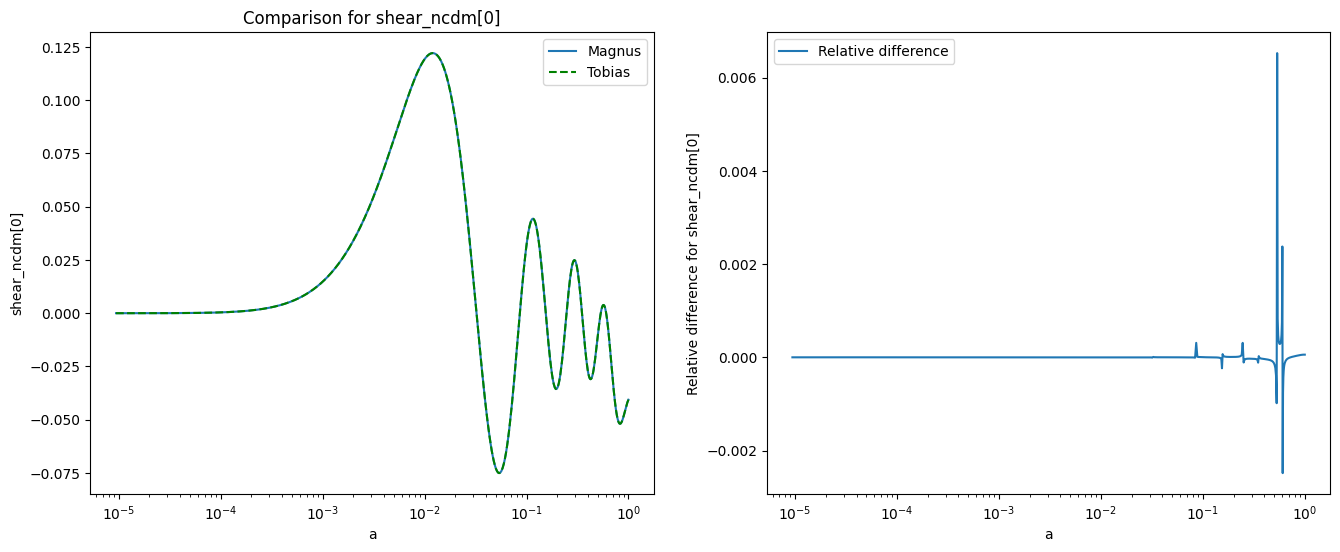

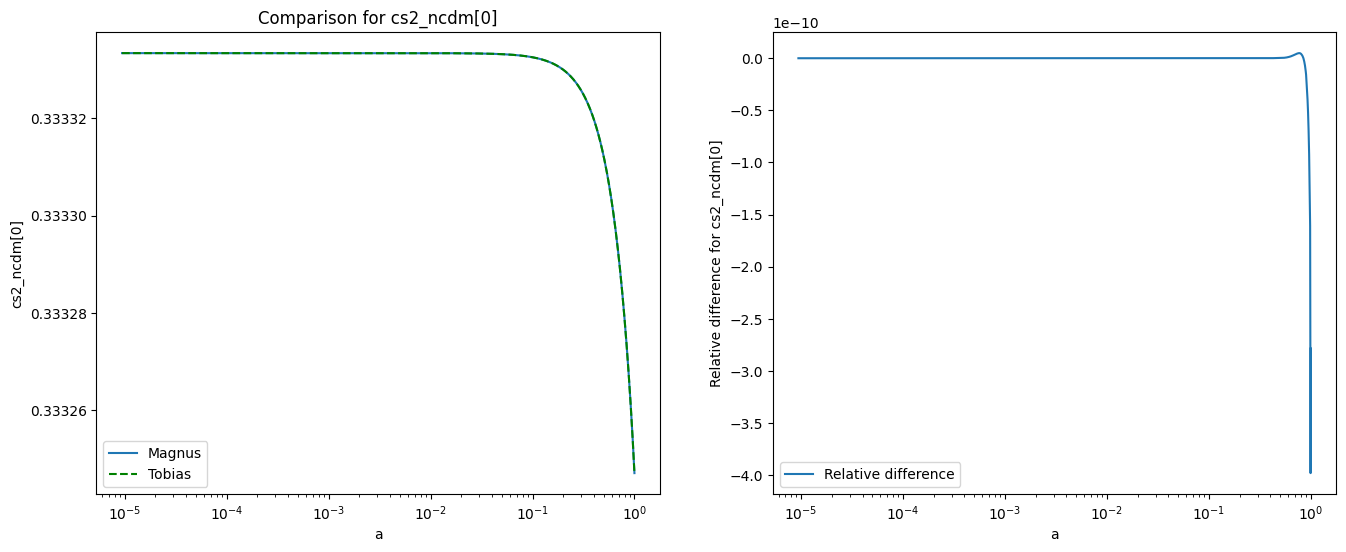

In [7]:
perturbations_Magnus_ncdm = model_Magnus_ncdm.get_perturbations()['scalar'][0]
perturbations_Tobias_ncdm = model_Tobias_ncdm.get_perturbations()['scalar'][0]
perturbations_reference_ncdm = model_reference_ncdm.get_perturbations()['scalar'][0]

a_Magnus = perturbations_Magnus_ncdm['a']
a_reference = perturbations_reference_ncdm['a']
a_Tobias = perturbations_Tobias_ncdm['a']
for key in perturbations_Magnus_ncdm.keys():
    if key == 'a':
        continue
    

    fig, axs = plt.subplots(1,2,figsize=(16,6))
    axs[0].plot(a_Magnus, perturbations_Magnus_ncdm[key], label='Magnus', ls='solid')
    #ax.plot(a_reference, perturbations_reference_ncdm[key], label='Reference', ls='dotted', lw =2, color = 'magenta')
    axs[0].plot(a_Tobias, perturbations_Tobias_ncdm[key], label='Tobias', ls='dashed', color = 'green')
    axs[0].set(xlabel='a', ylabel=key, xscale='log')
    #ax.invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    axs[0].set_title(f'Comparison for {key}')
    axs[0].legend()

    #Create a logscale plot of the relative difference between Magnus and Tobias. First, we need to interpolate the Tobias data to the same a values as Magnus.
    interp_Tobias = interp1d(a_Tobias, perturbations_Tobias_ncdm[key], kind='cubic', fill_value='extrapolate')
    Tobias_interp = interp_Tobias(a_Magnus)

    relative_difference = (perturbations_Magnus_ncdm[key] - Tobias_interp) / perturbations_Magnus_ncdm[key]
    axs[1].plot(a_Magnus, relative_difference, label='Relative difference', ls='solid')
    axs[1].set(xlabel='a', ylabel=f'Relative difference for {key}', xscale='log')
    axs[1].legend()


for key in perturbations_Magnus_ncdm.keys():
    print(key)

for key in perturbations_Tobias_ncdm.keys():
    print(key)

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-03
Running CLASS version v3.2.5
Computing background
 -> non-cold dark matter species with i=1 has m_i = 1.000000e-05 eV (so m_i / omega_i =1.756884e+00 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
Chose ndf15 as generic_evolver
 -> age = 13.858042 Gyr
 -> conformal age = 14242.901235 Mpc
 -> N_eff = 1.0132 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 4666.945526
    corresponding to conformal time = 96.464596 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0490087       , omega = 0.022          
-> Cold

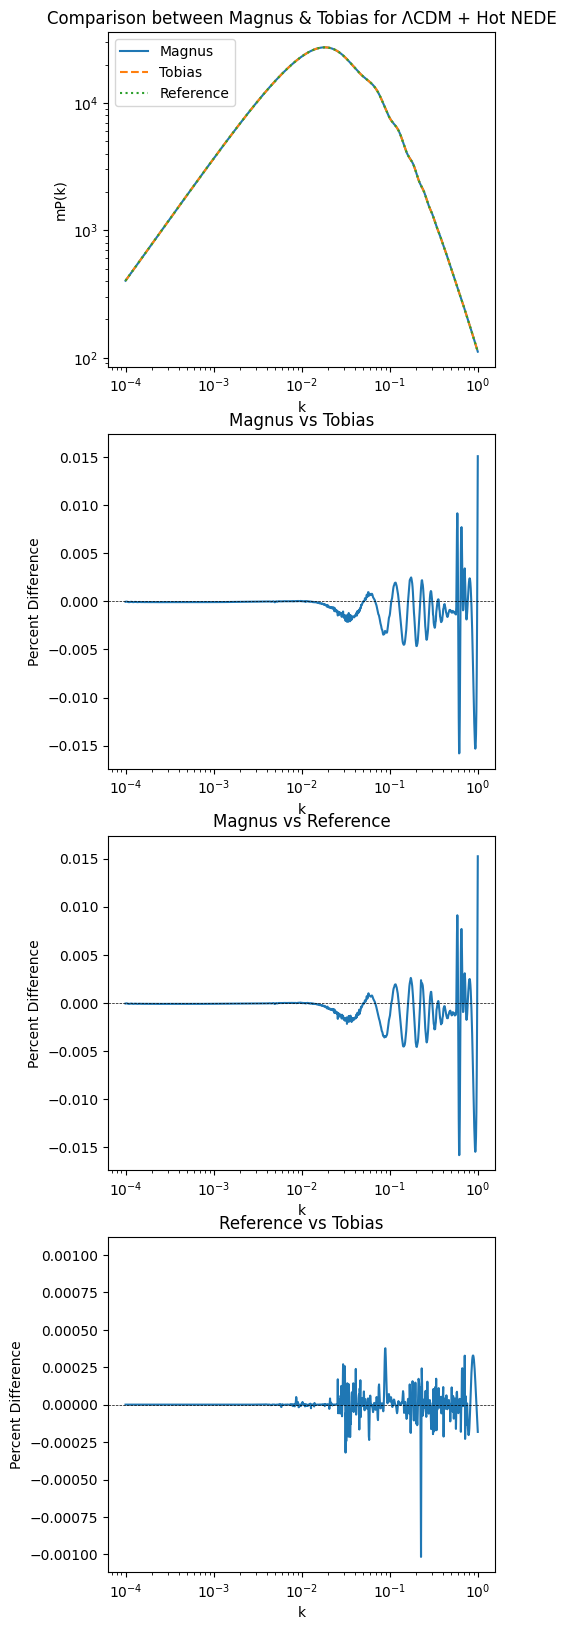

In [8]:
fig, axs = plt.subplots(4,1, figsize=(5,20))

axs[0].set(xscale='log', yscale='log', xlabel="k", ylabel="mP(k)")
axs[0].set_title('Comparison between Magnus & Tobias for ΛCDM + Hot NEDE')

klist_Magnus, mPk_Magnus = plot_mPk(model_Magnus_ncdm, axs[0], label='Magnus', ls='solid')
klist_Tobias, mPk_Tobias = plot_mPk(model_Tobias_ncdm, axs[0], label='Tobias', ls='dashed')
klist_Reference, mPk_Reference = plot_mPk(model_reference_ncdm, axs[0], label='Reference', ls='dotted')
axs[0].legend()

axs[1].plot(klist_Magnus, (mPk_Magnus - mPk_Tobias) / mPk_Tobias * 100, label = 'Magnus - Tobias')
axs[1].set(xlabel='k', ylabel='Percent Difference', xscale='log')
axs[1].set_title('Magnus vs Tobias')
axs[1].set_ylim(- max(abs((mPk_Magnus - mPk_Tobias) / mPk_Tobias * 100)) * 1.1, max(abs((mPk_Magnus - mPk_Tobias) / mPk_Tobias * 100)) * 1.1)
axs[1].axhline(0, color='black', lw=0.5, ls='--')

axs[2].plot(klist_Magnus, (mPk_Magnus - mPk_Reference) / mPk_Reference * 100, label = 'Magnus - Reference')
axs[2].set(xlabel='k', ylabel='Percent Difference', xscale='log')
axs[2].set_title('Magnus vs Reference')
axs[2].set_ylim(- max(abs((mPk_Magnus - mPk_Reference) / mPk_Reference * 100)) * 1.1, max(abs((mPk_Magnus - mPk_Reference) / mPk_Reference * 100)) * 1.1)
axs[2].axhline(0, color='black', lw=0.5, ls='--')

axs[3].plot(klist_Tobias, -(mPk_Tobias - mPk_Reference) / mPk_Tobias * 100, label = 'Reference - Tobias')
axs[3].set(xlabel='k', ylabel='Percent Difference', xscale='log')
axs[3].set_title('Reference vs Tobias')
axs[3].set_ylim(- max(abs((mPk_Reference - mPk_Tobias) / mPk_Tobias * 100)) * 1.1, max(abs((mPk_Reference - mPk_Tobias) / mPk_Tobias * 100)) * 1.1)
axs[3].axhline(0, color='black', lw=0.5, ls='--')

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-03
Running CLASS version v3.2.5
Computing background
 -> non-cold dark matter species with i=1 has m_i = 1.000000e-05 eV (so m_i / omega_i =1.756884e+00 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
Chose ndf15 as generic_evolver
 -> age = 13.858042 Gyr
 -> conformal age = 14242.901235 Mpc
 -> N_eff = 1.0132 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 4666.945526
    corresponding to conformal time = 96.464596 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0490087       , omega = 0.022          
-> Cold

/tmp/ipykernel_120601/1190622446.py:11: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias * 100, label = 'Magnus - Tobias')
/tmp/ipykernel_120601/1190622446.py:18: RuntimeWarning: invalid value encountered in divide
  for data in (cl_Magnus - cl_Tobias) / cl_Tobias * 100:
/tmp/ipykernel_120601/1190622446.py:31: RuntimeWarning: invalid value encountered in divide
  axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference * 100, label = 'Magnus - Reference')
/tmp/ipykernel_120601/1190622446.py:36: RuntimeWarning: invalid value encountered in divide
  for data in (cl_Magnus - cl_Reference) / cl_Reference * 100:
/tmp/ipykernel_120601/1190622446.py:45: RuntimeWarning: invalid value encountered in divide
  axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias * 100, label = 'Reference - Tobias')
/tmp/ipykernel_120601/1190622446.py:50: RuntimeWarning: invalid value encountered in divide
  for data in (cl_Reference - 

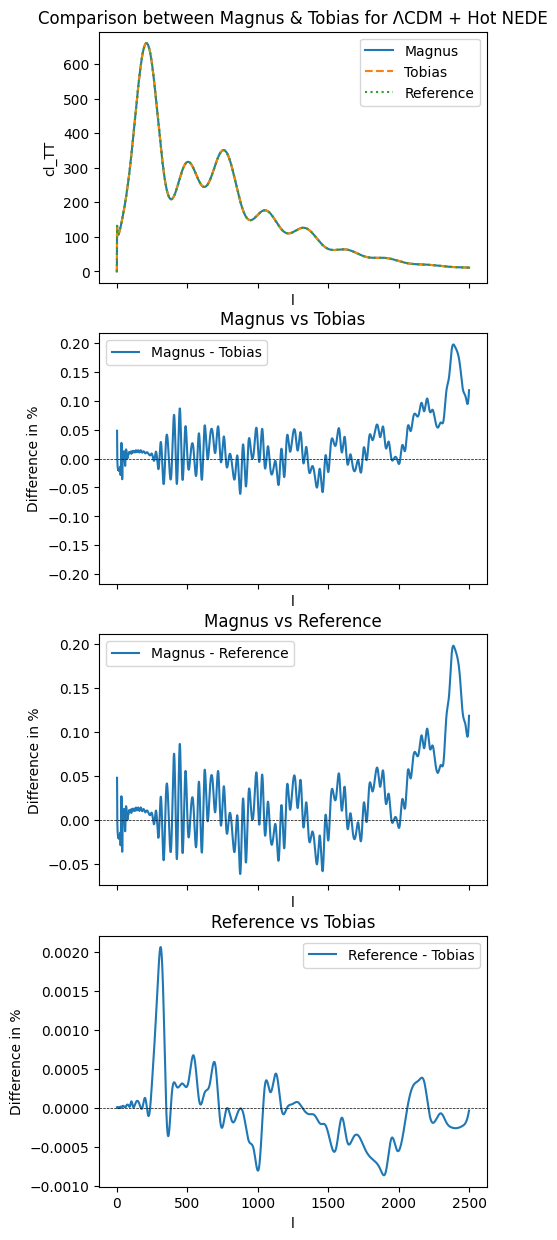

In [9]:
fig, axs = plt.subplots(4,1, figsize=(5,15), sharex=True)

axs[0].set(xlabel="l", ylabel="cl_TT")
axs[0].set_title('Comparison between Magnus & Tobias for ΛCDM + Hot NEDE')

l_Magnus, cl_Magnus = plot_Cl_TT(model_Magnus_ncdm, axs[0], label='Magnus', ls='solid')
l_Tobias, cl_Tobias = plot_Cl_TT(model_Tobias_ncdm, axs[0], label='Tobias', ls='dashed')
l_Reference, cl_Reference = plot_Cl_TT(model_reference_ncdm, axs[0], label='Reference', ls='dotted')
axs[0].legend()

axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias * 100, label = 'Magnus - Tobias')
axs[1].set(xlabel='l', ylabel='Difference in %')
axs[1].set_title('Magnus vs Tobias')


## set the limits to 1.1 times the maximum absolute non-inf or non-nan value of the relative difference, but if any element:
max_value = 0
for data in (cl_Magnus - cl_Tobias) / cl_Tobias * 100:
    if np.isnan(data) or np.isinf(data):
        continue
    if abs(data) > max_value:
        max_value = abs(data)

axs[1].set_ylim(- max_value * 1.1, max_value * 1.1)



axs[1].axhline(0, color='black', lw=0.5, ls='--')
axs[1].legend()

axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference * 100, label = 'Magnus - Reference')
axs[2].set(xlabel='l', ylabel= 'Difference in %')
axs[2].set_title('Magnus vs Reference')

max_value = 0
for data in (cl_Magnus - cl_Reference) / cl_Reference * 100:
    if np.isnan(data) or np.isinf(data):
        continue
    if abs(data) > max_value:
        max_value = abs(data)

axs[2].axhline(0, color='black', lw=0.5, ls='--')
axs[2].legend()

axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias * 100, label = 'Reference - Tobias')
axs[3].set(xlabel='l', ylabel='Difference in %')
axs[3].set_title('Reference vs Tobias')

max_value = 0
for data in (cl_Reference - cl_Tobias) / cl_Tobias * 100:
    if np.isnan(data) or np.isinf(data):
        continue
    if abs(data) > max_value:
        max_value = abs(data)
   
axs[3].axhline(0, color='black', lw=0.5, ls='--')
axs[3].legend()

/tmp/ipykernel_120601/2087779012.py:12: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias)
/tmp/ipykernel_120601/2087779012.py:16: RuntimeWarning: invalid value encountered in divide
  axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference)
/tmp/ipykernel_120601/2087779012.py:20: RuntimeWarning: invalid value encountered in divide
  axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias)


Text(0.5, 1.0, 'Reference vs Tobias')

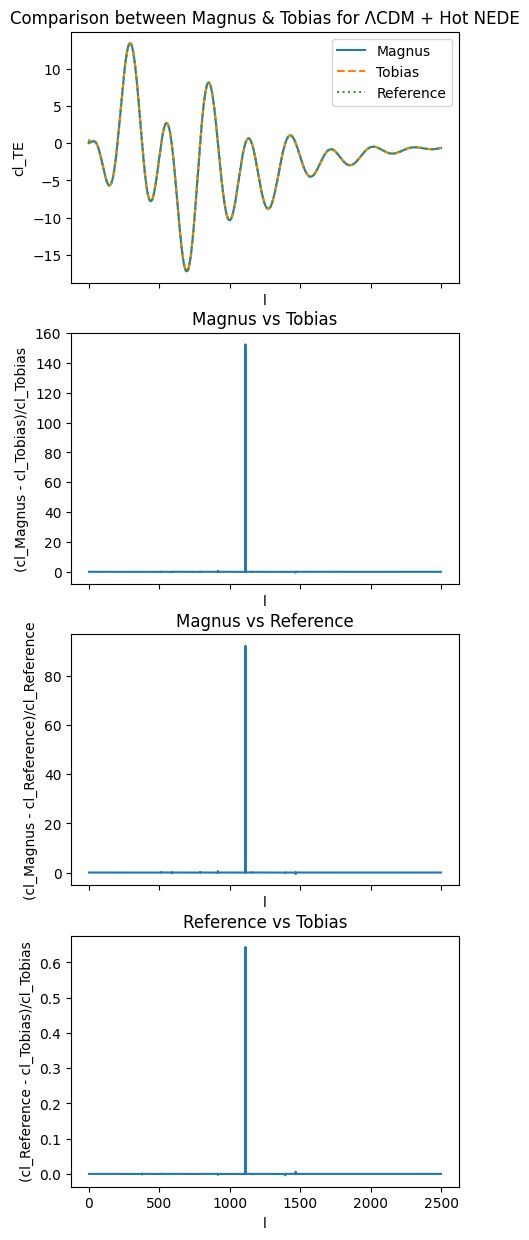

In [10]:
fig, axs = plt.subplots(4,1, figsize=(5,15), sharex=True)

axs[0].set(xlabel="l", ylabel="cl_TE")
axs[0].set_title('Comparison between Magnus & Tobias for ΛCDM + Hot NEDE')


l_Magnus, cl_Magnus = plot_Cl_TE(model_Magnus_ncdm, axs[0], label='Magnus', ls='solid')
l_Tobias, cl_Tobias = plot_Cl_TE(model_Tobias_ncdm, axs[0], label='Tobias', ls='dashed')
l_Reference, cl_Reference = plot_Cl_TE(model_reference_ncdm, axs[0], label='Reference', ls='dotted')
axs[0].legend()

axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias)
axs[1].set(xlabel='l', ylabel='(cl_Magnus - cl_Tobias)/cl_Tobias')
axs[1].set_title('Magnus vs Tobias')

axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference)
axs[2].set(xlabel='l', ylabel='(cl_Magnus - cl_Reference)/cl_Reference')
axs[2].set_title('Magnus vs Reference')

axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias)
axs[3].set(xlabel='l', ylabel='(cl_Reference - cl_Tobias)/cl_Tobias')
axs[3].set_title('Reference vs Tobias')